#RQ2 - Do male and female participants differ in process‑level cognitive effort during code comprehension, as reflected in global eye‑tracking metrics (fixation count, total fixation time, mean fixation duration, saccade length) and gaze-derived timing measures (time spent on the code stimulus, time to answer), after controlling for programming expertise and task type? (And task correctness, task effects)

RQ2 focuses on process‑level cognitive effort, which refers to the mental work participants invest while reading and understanding source code. Global eye‑tracking metrics such as fixation count, total fixation time, mean fixation duration, saccade length, and scanpath length are widely used indicators of cognitive effort in visual cognition research. Behavioural timing measures such as time spent on the stimulus and time to answer further reflect the overall processing load. Together, these metrics capture how participants process the code as a whole, independent of where they look or how they read line‑by‑line

# Mount and import

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/EMIP-Toolkit')
sys.path.append('/content/drive/MyDrive/EMIP-Toolkit/emtk')
sys.path.append('/content/drive/MyDrive/EMIP-Toolkit/emtk/parsers')

In [ ]:
import parsers
import aoi
import visualization
import util

In [ ]:
import os
import pandas as pd
import numpy as np

In [ ]:
DATA_LOSS_THRESHOLD = 70.0

In [ ]:
RAWDATA = "emtk/datasets/EMIP/EMIP-Toolkit- replication package/emip_dataset/rawdata"

# Testing for Validity Column in raw samples


In [ ]:
desired_path = '/content/drive/MyDrive/EMIP-Toolkit'
os.chdir(desired_path)

In [ ]:
def process_batch(batch, invalid_values):
    """Process a batch of TSV lines, extracting timestamp + R Validity safely."""
    valid_lines = 0
    invalid_lines = 0
    for line in batch:
        cols = line.split("\t")

        # We ONLY care about SMP rows
        if len(cols) < 2:
            continue
        if cols[1] != "SMP":
            continue

        # Check timestamp exists
        timestamp = cols[0].strip() if len(cols) > 0 else None

        # Safely extract R Validity (col 27)
        if len(cols) > 27:
            r_validity = cols[27].strip()
        else:
            # Missing R validity — treat as invalid
            r_validity = "MISSING"

        # Check if invalid
        if r_validity not in ("0", "1"):
            invalid_values.add(r_validity)
        else:
          if r_validity == "1":
            valid_lines += 1
          else:
            invalid_lines += 1

    return valid_lines, invalid_lines


In [ ]:

# Global counters
files_all_valid = 0
files_with_invalid = 0


def check_validity_in_batches(tsv_path, batch_size=10):
    """
    Stream-reads a TSV file in small batches.
    Extracts timestamp + R-validity only from SMP rows.
    Tracks invalid R-validity values.
    """
    global files_all_valid, files_with_invalid


    print(f"\nChecking file: {os.path.basename(tsv_path)}")

    invalid_values = set()
    total_lines = 0
    total_valid_lines = 0
    total_invalid_lines =0
    participant_id = os.path.basename(tsv_path).split("_")[0]
    batch = []


    with open(tsv_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            total_lines += 1

            if not line.strip():
                continue

            batch.append(line)

            if len(batch) >= batch_size:
                valid_lines, invalid_lines = process_batch(batch, invalid_values)
                total_valid_lines += valid_lines
                total_invalid_lines += invalid_lines
                batch = []

        # last partial batch
        if batch:
            process_batch(batch, invalid_values)

    # ---- Summary for THIS file ----
    if invalid_values:
        print(f" Invalid R Validity values: {invalid_values}")
        files_with_invalid += 1
    else:
        print(f" All R Validity values are 0 or 1.")
        files_all_valid += 1

    print(f"Processed {total_lines} lines.")
    print(f"Valid lines: {total_valid_lines}")
    print(f"Invalid lines: {total_invalid_lines}")
    percentage_valid = (total_valid_lines / total_lines) * 100
    print(f"Percentage of valid lines: {percentage_valid}")
    if percentage_valid >= DATA_LOSS_THRESHOLD:
      valid_participants.add(participant_id)



In [ ]:

global valid_participants
valid_participants = set()
for root, dirs, files in os.walk(RAWDATA):
    for fname in files:
        if fname.endswith(".tsv") and fname[0].isdigit():
           check_validity_in_batches(os.path.join(root, fname), batch_size=10)


# ---------------------------
# FINAL GLOBAL SUMMARY
# ---------------------------
print("\n====================++====SUMMARY=====++======================")
print(f"Files with ONLY R-validity values (0 or 1):  {files_all_valid}")
print(f"Files with R-validity values other than 0/1: {files_with_invalid}")
print(f"Valid participants: {valid_participants}")
print(f"Total valid participants: {len(valid_participants)}")
print("=================================================================\n")



Checking file: 99_rawdata.tsv
 All R Validity values are 0 or 1.
Processed 49759 lines.
Valid lines: 48848
Invalid lines: 853
Percentage of valid lines: 98.16917542555116

Checking file: 96_rawdata.tsv
 All R Validity values are 0 or 1.
Processed 47777 lines.
Valid lines: 40753
Invalid lines: 6968
Percentage of valid lines: 85.29836532222618

Checking file: 97_rawdata.tsv
 All R Validity values are 0 or 1.
Processed 49360 lines.
Valid lines: 48757
Invalid lines: 554
Percentage of valid lines: 98.77836304700162

Checking file: 91_rawdata.tsv
 All R Validity values are 0 or 1.
Processed 34786 lines.
Valid lines: 32957
Invalid lines: 1774
Percentage of valid lines: 94.74213764157994

Checking file: 85_rawdata.tsv
 All R Validity values are 0 or 1.
Processed 37146 lines.
Valid lines: 35745
Invalid lines: 1351
Percentage of valid lines: 96.22839605879503

Checking file: 9_rawdata.tsv
 All R Validity values are 0 or 1.
Processed 48338 lines.
Valid lines: 33281
Invalid lines: 15005
Percentag

# Trackability threshold


In [ ]:
desired_path = '/content/drive/MyDrive/EMIP-Toolkit'
os.chdir(desired_path)

In [ ]:
def check_code_reading_validity(tsv_path):
    participant_id = os.path.basename(tsv_path).split("_")[0]

    in_code_section = False
    total_samples = 0
    valid_samples = 0

    with open(tsv_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            cols = line.split("\t")
            if len(cols) < 2:
                continue

            row_type = cols[1].strip()

            if row_type == "MSG":
                if len(cols) > 3:
                    raw = cols[3].strip()
                    stimulus = cols[3].split(' ')[-1]
                    if stimulus.startswith("vehicle") or stimulus.startswith("rectangle"):
                        in_code_section = True
                    else:
                        in_code_section = False

            elif row_type == "SMP" and in_code_section:
                total_samples += 1
                r_validity = cols[27].strip() if len(cols) > 27 else None
                if r_validity == "1":
                    valid_samples += 1

    if total_samples == 0:
        print(f"[{participant_id}] No SMP samples found during code-reading sections.")
        return participant_id, None

    pct_valid = (valid_samples / total_samples) * 100
    print(f"[{participant_id}] Code-reading samples: {total_samples} | "
          f"Valid: {valid_samples} | {pct_valid:.1f}%")
    return participant_id, pct_valid




In [ ]:
# ── Run ──────────────────────────────────────────────────────────────────────

results = {}

for root, dirs, files in os.walk(RAWDATA):
    for fname in files:
        if fname.endswith(".tsv") and fname[0].isdigit():
            pid, pct = check_code_reading_validity(os.path.join(root, fname))
            results[pid] = pct

# ── Summary ──────────────────────────────────────────────────────────────────

trackable_participants = {pid for pid, pct in results.items()
                      if pct is not None and pct >= DATA_LOSS_THRESHOLD}

print("\n==================== SUMMARY ====================")
for pid, pct in sorted(results.items()):
    pct_str = f"{pct:.1f}%" if pct is not None else "N/A"
    print(f"  {pid}: {pct_str} valid during code reading")

print(f"\nValid participants (>= {DATA_LOSS_THRESHOLD}%): {len(trackable_participants)}")
print(f"Length of valid participants {len(trackable_participants)}")
print("==================================================\n")

[99] Code-reading samples: 27701 | Valid: 27334 | 98.7%
[96] Code-reading samples: 29419 | Valid: 28836 | 98.0%
[97] Code-reading samples: 27900 | Valid: 27675 | 99.2%
[91] Code-reading samples: 23765 | Valid: 22585 | 95.0%
[85] Code-reading samples: 24250 | Valid: 23215 | 95.7%
[9] Code-reading samples: 27806 | Valid: 16529 | 59.4%
[94] Code-reading samples: 19357 | Valid: 19025 | 98.3%
[93] Code-reading samples: 9420 | Valid: 8383 | 89.0%
[87] Code-reading samples: 30532 | Valid: 27100 | 88.8%
[90] Code-reading samples: 8674 | Valid: 8478 | 97.7%
[83] Code-reading samples: 38912 | Valid: 37522 | 96.4%
[8] Code-reading samples: 50358 | Valid: 43460 | 86.3%
[74] Code-reading samples: 14902 | Valid: 13351 | 89.6%
[88] Code-reading samples: 29053 | Valid: 27327 | 94.1%
[84] Code-reading samples: 36312 | Valid: 32235 | 88.8%
[98] Code-reading samples: 18734 | Valid: 7431 | 39.7%
[81] Code-reading samples: 26643 | Valid: 26399 | 99.1%
[76] Code-reading samples: 32269 | Valid: 28903 | 89.6%

In [ ]:
print(f"Number of participants in valid_participants: {len(valid_participants)}")
print(f"Number of participants in trackable_participants: {len(trackable_participants)}")

# Find common participants
common_participants = valid_participants.intersection(trackable_participants)
print(f"\nCommon participants ({len(common_participants)}): {sorted(list(common_participants))}")

# Find participants in valid_participants but not in trackable_participants
valid_but_not_trackable = valid_participants.difference(trackable_participants)
if valid_but_not_trackable:
    print(f"\nParticipants in valid_participants but NOT in trackable_participants ({len(valid_but_not_trackable)}): {sorted(list(valid_but_not_trackable))}")
else:
    print("\nAll participants in valid_participants are also in trackable_participants.")

# Find participants in trackable_participants but not in valid_participants
trackable_but_not_valid = trackable_participants.difference(valid_participants)
if trackable_but_not_valid:
    print(f"\nParticipants in trackable_participants but NOT in valid_participants ({len(trackable_but_not_valid)}): {sorted(list(trackable_but_not_valid))}")
else:
    print("\nAll participants in trackable_participants are also in valid_participants.")

# Check if sets are identical
if valid_participants == trackable_participants:
    print("\nThe sets valid_participants and trackable_participants are identical.")
else:
    print("\nThe sets valid_participants and trackable_participants are NOT identical.")

Number of participants in valid_participants: 187
Number of participants in trackable_participants: 188

Common participants (183): ['10', '100', '101', '105', '106', '107', '108', '109', '11', '110', '112', '113', '114', '115', '116', '117', '118', '119', '12', '120', '121', '122', '123', '124', '126', '128', '13', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '14', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '15', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '16', '160', '161', '162', '163', '164', '165', '166', '168', '169', '17', '170', '171', '172', '175', '176', '177', '178', '179', '180', '181', '182', '183', '184', '185', '186', '187', '188', '189', '190', '191', '192', '193', '194', '195', '196', '197', '198', '2', '20', '200', '201', '202', '206', '207', '208', '21', '210', '211', '213', '214', '215', '216', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', 

# Load Participants

In [ ]:
MAX_DISPERSION = 68
MINIMUM_DURATION = 100

First half of participants 1 - 108

In [ ]:
desired_path = '/content/drive/MyDrive/EMIP-Toolkit'
os.chdir(desired_path)

In [ ]:
eye_events, samples, stimulus_time = parsers.EMIP(sample_size = 108,
                                                  process_raw_samples=False,
                                                  use_minus_one_for_invalid_gaze=False,
                                                  classifier="idt",
                                                  maximum_dispersion = MAX_DISPERSION,
                                                  minimum_duration = MINIMUM_DURATION)

Loaded metadata for 216 participants
Gender mapping created for 216 participants
Males: 175
Females: 41
Finished loading eye events for participants.


Second half of participants 109 - 216

In [ ]:
eye_events2, samples2, stimulus_time2 = parsers.EMIP(sample_size = 108,
                                                     start_index = 108,
                                                     process_raw_samples=False,
                                                     use_minus_one_for_invalid_gaze=False,
                                                     classifier="idt",
                                                     maximum_dispersion = MAX_DISPERSION,
                                                     minimum_duration = MINIMUM_DURATION)

Loaded metadata for 216 participants
Gender mapping created for 216 participants
Males: 175
Females: 41
Finished loading eye events for participants.


Combine the two batches of eye events

In [ ]:
eye_events = pd.concat([eye_events, eye_events2])

In [ ]:
eye_events.head()

,eye_tracker,experiment_id,participant_id,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,token,pupil,eye_event_type,gender
0,SMIRed250,1,1,1_rawdata.tsv,0,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_calibration.jpg,947809128,270.938,1532.046744,252.807907,"[1008043594, MSG, 1, # Message: instruction_co...",0,fixation,male
1,SMIRed250,1,1,1_rawdata.tsv,0,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_calibration.jpg,948829995,119.831,813.900667,513.561000,"[1008043594, MSG, 1, # Message: instruction_co...",0,fixation,male
2,SMIRed250,1,1,1_rawdata.tsv,1,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_comprehension.jpg,1008594653,188.028,990.360833,432.789583,"[1020309277, MSG, 1, # Message: vehicle_java.jpg]",0,fixation,male
3,SMIRed250,1,1,1_rawdata.tsv,1,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_comprehension.jpg,1008798679,95.991,925.132400,408.627200,"[1020309277, MSG, 1, # Message: vehicle_java.jpg]",0,fixation,male
4,SMIRed250,1,1,1_rawdata.tsv,1,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_comprehension.jpg,1009110603,99.997,790.459231,285.858462,"[1020309277, MSG, 1, # Message: vehicle_java.jpg]",0,fixation,male


Merge samples if loaded

In [ ]:
if samples and not samples.empty and samples2 and not samples2.empty:
    samples = pd.concat([samples, samples2])

In [ ]:
if samples and not samples.empty:
  samples.head()
else:
  print("Raw samples not loaded")

Raw samples not loaded


In [ ]:
#find unique participants and number of participants in data frame eye_events
unique_participants = eye_events['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants in the dataset are" + str(unique_participants))

There are 216 Participants in the dataset are['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15' '16'
 '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28' '29' '30'
 '31' '32' '33' '34' '35' '36' '37' '38' '39' '40' '41' '42' '43' '44'
 '45' '46' '47' '48' '49' '50' '51' '52' '53' '54' '55' '56' '57' '58'
 '59' '60' '61' '62' '63' '64' '65' '66' '67' '68' '69' '70' '71' '72'
 '73' '74' '75' '76' '77' '78' '79' '80' '81' '82' '83' '84' '85' '86'
 '87' '88' '89' '90' '91' '92' '93' '94' '95' '96' '97' '98' '99' '100'
 '101' '102' '103' '104' '105' '106' '107' '108' '109' '110' '111' '112'
 '113' '114' '115' '116' '117' '118' '119' '120' '121' '122' '123' '124'
 '125' '126' '127' '128' '129' '130' '131' '132' '133' '134' '135' '136'
 '137' '138' '139' '140' '141' '142' '143' '144' '145' '146' '147' '148'
 '149' '150' '151' '152' '153' '154' '155' '156' '157' '158' '159' '160'
 '161' '162' '163' '164' '165' '166' '167' '168' '169' '170' '171' '172'
 '173' '174' '175'

Combine time spent on each stimulus




In [ ]:
stimulus_time = pd.concat([stimulus_time, stimulus_time2])

In [ ]:
display(stimulus_time)
display(len(stimulus_time))

,participant_id,gender,trial,stimulus_name,start_timestamp,end_timestamp,time_spenton_stimuli
0,1,male,0,instruction_calibration.jpg,945553890,952864364,7310474
1,1,male,1,instruction_comprehension.jpg,1008050652,1020308008,12257356
2,1,male,2,vehicle_java.jpg,1020312074,1097995373,77683299
3,1,male,3,mupliple_choice_vehicle.jpg,1097999372,1137882278,39882906
4,1,male,4,instruction_comprehension.jpg,1137916069,1145160532,7244463
...,...,...,...,...,...,...,...
751,216,female,2,vehicle_java2.jpg,406962816,481100215,74137399
752,216,female,3,mupliple_choice_vehicle.jpg,481116216,497818826,16702610
753,216,female,4,instruction_comprehension.jpg,497838818,502194738,4355920
754,216,female,5,rectangle_java2.jpg,502198746,535731617,33532871


1512

The interval between two consecutive timestamps is 3994 indicating that the unit of time used in the raw data is microseconds. For 250Hz SMI RED250 tracker, one data point is captured every 4 ms, which equals 4000 microseconds - 3994 is a slight variation that could have been caused due to minor fluctuations in hardware's internal clock or processing overhead. Safe to assume that the timestamp captured is in microseconds and time spent on any stimulus can be calculated as End Timestamp - Start Timestamp divided by 1000,000

In [ ]:
#Adding an extra column to convert the time spent on stimulus to seconds from microseconds
stimulus_time['tss_second'] = stimulus_time['time_spenton_stimuli'] / 1000000

# Filter out the ones with more than threshold of data loss


In [ ]:
#find the number of unique participants in eye_events
unique_participants = eye_events['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants in the dataset are" + str(unique_participants))
#find the number of unique participants in stimulus_time
unique_participants = stimulus_time['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants in the dataset are" + str(unique_participants))

There are 216 Participants in the dataset are['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15' '16'
 '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28' '29' '30'
 '31' '32' '33' '34' '35' '36' '37' '38' '39' '40' '41' '42' '43' '44'
 '45' '46' '47' '48' '49' '50' '51' '52' '53' '54' '55' '56' '57' '58'
 '59' '60' '61' '62' '63' '64' '65' '66' '67' '68' '69' '70' '71' '72'
 '73' '74' '75' '76' '77' '78' '79' '80' '81' '82' '83' '84' '85' '86'
 '87' '88' '89' '90' '91' '92' '93' '94' '95' '96' '97' '98' '99' '100'
 '101' '102' '103' '104' '105' '106' '107' '108' '109' '110' '111' '112'
 '113' '114' '115' '116' '117' '118' '119' '120' '121' '122' '123' '124'
 '125' '126' '127' '128' '129' '130' '131' '132' '133' '134' '135' '136'
 '137' '138' '139' '140' '141' '142' '143' '144' '145' '146' '147' '148'
 '149' '150' '151' '152' '153' '154' '155' '156' '157' '158' '159' '160'
 '161' '162' '163' '164' '165' '166' '167' '168' '169' '170' '171' '172'
 '173' '174' '175'

In [ ]:
#in eye_events and stimulus_time only keep those participants where participant_id is in valid_participants set
eye_events = eye_events[eye_events['participant_id'].isin(trackable_participants)]
stimulus_time = stimulus_time[stimulus_time['participant_id'].isin(trackable_participants)]

In [ ]:
#find the number of unique participants in eye_events
unique_participants = eye_events['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants afer filtering are" + str(unique_participants))
#find the number of unique participants in stimulus_time
unique_participants = stimulus_time['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants after filtering are" + str(unique_participants))

There are 188 Participants afer filtering are['2' '3' '4' '5' '6' '7' '8' '10' '11' '12' '13' '14' '15' '16' '17' '18'
 '20' '21' '23' '24' '25' '26' '27' '28' '29' '30' '31' '32' '33' '34'
 '35' '36' '37' '38' '39' '40' '42' '43' '44' '45' '46' '47' '48' '49'
 '51' '53' '54' '55' '56' '57' '58' '59' '60' '61' '62' '63' '64' '68'
 '69' '70' '71' '72' '73' '74' '75' '76' '78' '79' '80' '81' '82' '83'
 '84' '85' '86' '87' '88' '89' '90' '91' '93' '94' '95' '96' '97' '99'
 '100' '101' '105' '106' '107' '108' '109' '110' '112' '113' '114' '115'
 '116' '117' '118' '119' '120' '121' '122' '123' '124' '126' '128' '130'
 '131' '132' '133' '134' '135' '136' '137' '138' '139' '140' '141' '142'
 '143' '144' '145' '146' '147' '148' '149' '150' '151' '152' '153' '154'
 '155' '156' '157' '158' '159' '160' '161' '162' '163' '164' '165' '166'
 '167' '168' '169' '170' '171' '172' '175' '176' '177' '178' '179' '180'
 '181' '182' '183' '184' '185' '186' '187' '188' '189' '190' '191' '192'
 '193' '194' '1

#Load metadata


Load gender map





In [ ]:
desired_path = os.path.join(
    '/content/drive/MyDrive/EMIP-Toolkit/emtk/datasets/EMIP',
    'EMIP-Toolkit- replication package',
    'emip_dataset'
)

os.chdir(desired_path)

In [ ]:
from collections import Counter
METADATA_FILE = 'emip_metadata.csv'
try:
    metadata_df = pd.read_csv(METADATA_FILE)
    print(f"Loaded metadata for {len(metadata_df)} participants")

except FileNotFoundError:
    print(f"Warning: Metadata file '{METADATA_FILE}' not found")
except Exception as e:
    print(f"Error loading metadata: {e}.")

Loaded metadata for 216 participants


In [ ]:
metadata_df.head()

,id,age,gender,mother_tongue,english_level,visual_aid,makeup,experiment_language,expertise_experiment_language,time_experiment_language,...,order_rectangle,stimulus_rectangle,answer_vehicle,correct_vehicle,order_vehicle,stimulus_vehicle,mother_tongue_original,time_experiment_language_original,time_programming_original,other_languages_original
0,1,63,male,Czech,high,glasses,no,Java,high,30.0,...,2,rectangle_java.jpg,"... defines a vehicle by a producer, that has ...",0,1,vehicle_java.jpg,czech,30y,40+,CoffeeScript (high) JavaScript (high) Python (...
1,2,24,male,Slovak,medium,glasses,no,Java,medium,2.0,...,1,rectangle_java2.jpg,"... defines a vehicle by a producer, that has ...",0,2,vehicle_java2.jpg,Slovak,2,5,"c++(low), php(medium), delphi(low)"
2,3,27,female,Hebrew,high,no,no,Java,none,0.0,...,2,rectangle_java2.jpg,"... defines a vehicle by a producer, that has ...",0,1,vehicle_java2.jpg,Hebrew,0,0,c# (low)
3,4,24,male,Hindi,high,glasses,no,Java,medium,4.0,...,1,rectangle_java2.jpg,"... defines a vehicle by a producer, that has ...",0,2,vehicle_java2.jpg,Hindi,4,10,Python(High) C++(High) C(High) HTML/PHP/SQL (H...
4,5,24,male,Italian,medium,no,no,Java,none,0.0,...,1,rectangle_java2.jpg,"... defines a vehicle by a producer, that has ...",0,2,vehicle_java2.jpg,italiano,0,5,"objective C , C"


In [ ]:

def infer_order(row):
    if row['order_vehicle'] == 1:
        return 'vehicle_first'
    elif row['order_rectangle'] == 1:
        return 'rectangle_first'
    else:
        return None

metadata_df['order'] = metadata_df.apply(infer_order, axis=1)

# Binary version for models
metadata_df['order_bin'] = (metadata_df['order'] == 'vehicle_first').astype(int)

In [ ]:
exp_map = {'none':0, 'low':1, 'medium':2, 'high':3}
metadata_df['expertise_programming_num'] = metadata_df['expertise_programming'].map(exp_map)


In [ ]:
display(metadata_df)

,id,age,gender,mother_tongue,english_level,visual_aid,makeup,experiment_language,expertise_experiment_language,time_experiment_language,...,correct_vehicle,order_vehicle,stimulus_vehicle,mother_tongue_original,time_experiment_language_original,time_programming_original,other_languages_original,order,order_bin,expertise_programming_num
0,1,63,male,Czech,high,glasses,no,Java,high,30.0,...,0,1,vehicle_java.jpg,czech,30y,40+,CoffeeScript (high) JavaScript (high) Python (...,vehicle_first,1,3
1,2,24,male,Slovak,medium,glasses,no,Java,medium,2.0,...,0,2,vehicle_java2.jpg,Slovak,2,5,"c++(low), php(medium), delphi(low)",rectangle_first,0,2
2,3,27,female,Hebrew,high,no,no,Java,none,0.0,...,0,1,vehicle_java2.jpg,Hebrew,0,0,c# (low),vehicle_first,1,0
3,4,24,male,Hindi,high,glasses,no,Java,medium,4.0,...,0,2,vehicle_java2.jpg,Hindi,4,10,Python(High) C++(High) C(High) HTML/PHP/SQL (H...,rectangle_first,0,2
4,5,24,male,Italian,medium,no,no,Java,none,0.0,...,0,2,vehicle_java2.jpg,italiano,0,5,"objective C , C",rectangle_first,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,212,21,male,Slovak,high,glasses,no,Java,medium,2.0,...,1,2,vehicle_java2.jpg,slovak,2,3,"C (high), C++ (low)",rectangle_first,0,2
212,213,26,male,Hindi,high,no,no,Java,low,0.5,...,0,2,vehicle_java2.jpg,Hindi,6 months,3 years,Python(medium) VBA(High) Excel(High) C(medium),rectangle_first,0,2
213,214,21,male,Slovak,high,no,no,Java,medium,1.0,...,1,2,vehicle_java2.jpg,Slovak,1,4,"C (medium) , JavaScript (medium)",rectangle_first,0,2
214,215,22,male,Slovak,medium,no,no,Java,medium,1.0,...,1,1,vehicle_java2.jpg,slovak,1,2,C (medium) c# (medium) Java (medium),vehicle_first,1,2


# Fixation calculations


**Loading eye events for Vehicle code stimulus**

In [ ]:
vehicle_stim_events = eye_events[eye_events['stimuli_name'].str.startswith('vehicle')]


vehicle_stim_events['task'] = 'vehicle'
vehicle_stim_events =vehicle_stim_events.sort_values(by='participant_id')

unique_participants = vehicle_stim_events['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants for the vehicle code are" + str(unique_participants))

unique_participants = vehicle_stim_events[['participant_id', 'gender']].drop_duplicates()
gender_counts = unique_participants['gender'].value_counts()
print("This chunk of dataset contains " + str(gender_counts))

display(vehicle_stim_events[['participant_id', 'task','stimuli_name', 'gender']])


There are 188 Participants for the vehicle code are['10' '100' '101' '105' '106' '107' '108' '109' '11' '110' '112' '113'
 '114' '115' '116' '117' '118' '119' '12' '120' '121' '122' '123' '124'
 '126' '128' '13' '130' '131' '132' '133' '134' '135' '136' '137' '138'
 '139' '14' '140' '141' '142' '143' '144' '145' '146' '147' '148' '149'
 '15' '150' '151' '152' '153' '154' '155' '156' '157' '158' '159' '16'
 '160' '161' '162' '163' '164' '165' '166' '167' '168' '169' '17' '170'
 '171' '172' '175' '176' '177' '178' '179' '18' '180' '181' '182' '183'
 '184' '185' '186' '187' '188' '189' '190' '191' '192' '193' '194' '195'
 '196' '197' '198' '2' '20' '200' '201' '202' '206' '207' '208' '21' '210'
 '211' '213' '214' '215' '216' '23' '24' '25' '26' '27' '28' '29' '3' '30'
 '31' '32' '33' '34' '35' '36' '37' '38' '39' '4' '40' '42' '43' '44' '45'
 '46' '47' '48' '49' '5' '51' '53' '54' '55' '56' '57' '58' '59' '6' '60'
 '61' '62' '63' '64' '68' '69' '7' '70' '71' '72' '73' '74' '75' '76' '78'


/tmp/ipykernel_1955/1738347964.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vehicle_stim_events['task'] = 'vehicle'


,participant_id,task,stimuli_name,gender
6606,10,vehicle,vehicle_java.jpg,male
6545,10,vehicle,vehicle_java.jpg,male
6546,10,vehicle,vehicle_java.jpg,male
6547,10,vehicle,vehicle_java.jpg,male
6548,10,vehicle,vehicle_java.jpg,male
...,...,...,...,...
63718,99,vehicle,vehicle_java2.jpg,male
63717,99,vehicle,vehicle_java2.jpg,male
63716,99,vehicle,vehicle_java2.jpg,male
63724,99,vehicle,vehicle_java2.jpg,male


**Loading eye events for Rectangle code stimulus**

In [ ]:
rectangle_stim_events = eye_events[eye_events['stimuli_name'].str.startswith('rectangle')]
rectangle_stim_events = rectangle_stim_events.sort_values(by='participant_id')

rectangle_stim_events['task'] = 'rectangle'

unique_participants = rectangle_stim_events['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants for the rectangle code in java are" + str(unique_participants))

unique_participants = rectangle_stim_events[['participant_id', 'gender']].drop_duplicates()
gender_counts = unique_participants['gender'].value_counts()
print("This chunk of dataset contains " + str(gender_counts))

display(rectangle_stim_events[['participant_id', 'task','stimuli_name', 'gender']])



There are 188 Participants for the rectangle code in java are['10' '100' '101' '105' '106' '107' '108' '109' '11' '110' '112' '113'
 '114' '115' '116' '117' '118' '119' '12' '120' '121' '122' '123' '124'
 '126' '128' '13' '130' '131' '132' '133' '134' '135' '136' '137' '138'
 '139' '14' '140' '141' '142' '143' '144' '145' '146' '147' '148' '149'
 '15' '150' '151' '152' '153' '154' '155' '156' '157' '158' '159' '16'
 '160' '161' '162' '163' '164' '165' '166' '167' '168' '169' '17' '170'
 '171' '172' '175' '176' '177' '178' '179' '18' '180' '181' '182' '183'
 '184' '185' '186' '187' '188' '189' '190' '191' '192' '193' '194' '195'
 '196' '197' '198' '2' '20' '200' '201' '202' '206' '207' '208' '21' '210'
 '211' '213' '214' '215' '216' '23' '24' '25' '26' '27' '28' '29' '3' '30'
 '31' '32' '33' '34' '35' '36' '37' '38' '39' '4' '40' '42' '43' '44' '45'
 '46' '47' '48' '49' '5' '51' '53' '54' '55' '56' '57' '58' '59' '6' '60'
 '61' '62' '63' '64' '68' '69' '7' '70' '71' '72' '73' '74' '75' 

,participant_id,task,stimuli_name,gender
6356,10,rectangle,rectangle_java.jpg,male
6363,10,rectangle,rectangle_java.jpg,male
6364,10,rectangle,rectangle_java.jpg,male
6365,10,rectangle,rectangle_java.jpg,male
6366,10,rectangle,rectangle_java.jpg,male
...,...,...,...,...
63359,99,rectangle,rectangle_java2.jpg,male
63360,99,rectangle,rectangle_java2.jpg,male
63361,99,rectangle,rectangle_java2.jpg,male
63363,99,rectangle,rectangle_java2.jpg,male


In [ ]:
# Group by participant and gender, and count fixations
vehicle_fixation_summary = (
    vehicle_stim_events
    .groupby(['trial_id','stimuli_name', 'participant_id', 'gender'])
    .size()
    .reset_index(name='fixation_count')
    .sort_values(by='fixation_count')
)

# Display the result
print(vehicle_fixation_summary)

    trial_id       stimuli_name participant_id gender  fixation_count
125        5  vehicle_java2.jpg            112   male               2
7          2   vehicle_java.jpg            167   male              20
1          2   vehicle_java.jpg            130   male              25
91         2  vehicle_java2.jpg             90   male              26
142        5  vehicle_java2.jpg            156   male              37
..       ...                ...            ...    ...             ...
133        5  vehicle_java2.jpg            135   male             539
140        5  vehicle_java2.jpg            151   male             576
81         2  vehicle_java2.jpg             64   male             629
14         2   vehicle_java.jpg            202   male             724
122        5  vehicle_java2.jpg            101   male             796

[188 rows x 5 columns]


In [ ]:
# Group by participant and gender, and count fixations
rectangle_fixation_summary = (
    rectangle_stim_events
    .groupby(['trial_id','stimuli_name', 'participant_id', 'gender'])
    .size()
    .reset_index(name='fixation_count')
    .sort_values(by='fixation_count')
)

# Display the result
print(rectangle_fixation_summary)

    trial_id         stimuli_name participant_id  gender  fixation_count
95         5   rectangle_java.jpg            167    male               3
64         2  rectangle_java2.jpg             23    male              16
55         2  rectangle_java2.jpg            187  female              22
42         2  rectangle_java2.jpg            156    male              25
104        5   rectangle_java.jpg             39  female              30
..       ...                  ...            ...     ...             ...
46         2  rectangle_java2.jpg            168    male             426
30         2  rectangle_java2.jpg            132    male             466
80         2  rectangle_java2.jpg             86  female             475
93         5   rectangle_java.jpg            160    male             489
14         2   rectangle_java.jpg            194    male             492

[188 rows x 5 columns]


# Filter over minimum number of fixations

In [ ]:
MINIMUM_NUM_FIXATIONS = 5

In [ ]:
merged_vehicle_data = pd.merge(
    vehicle_stim_events,
    vehicle_fixation_summary[['participant_id', 'stimuli_name', 'fixation_count']],
    on=['participant_id', 'stimuli_name'],
    how='left'
)

vehicle_stim_events = merged_vehicle_data[merged_vehicle_data['fixation_count'] >= MINIMUM_NUM_FIXATIONS]

print(f"Number of participants in vehicle_stim_events after filtering: {vehicle_stim_events['participant_id'].nunique()}")


Number of participants in vehicle_stim_events after filtering: 187


In [ ]:
merged_rectangle_data = pd.merge(
    rectangle_stim_events,
    rectangle_fixation_summary[['participant_id', 'stimuli_name', 'fixation_count']],
    on=['participant_id', 'stimuli_name'],
    how='left'
)

rectangle_stim_events = merged_rectangle_data[merged_rectangle_data['fixation_count'] >= MINIMUM_NUM_FIXATIONS]

print(f"Number of participants in rectangle_stim_events after filtering: {rectangle_stim_events['participant_id'].nunique()}")

Number of participants in rectangle_stim_events after filtering: 187


# Combined sorted fixations computations

In [ ]:
common_participants = pd.Series(vehicle_stim_events['participant_id'].unique()).loc[
    pd.Series(vehicle_stim_events['participant_id'].unique()).isin(rectangle_stim_events['participant_id'].unique())
]

vehicle_stim_events_filtered = vehicle_stim_events[vehicle_stim_events['participant_id'].isin(common_participants)]
rectangle_stim_events_filtered = rectangle_stim_events[rectangle_stim_events['participant_id'].isin(common_participants)]

combined_fixations = pd.concat([vehicle_stim_events_filtered, rectangle_stim_events_filtered])
combined_fixations = combined_fixations.sort_values(['participant_id', 'task','timestamp'])
display(combined_fixations)

,eye_tracker,experiment_id,participant_id,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,token,pupil,eye_event_type,gender,task,fixation_count
41,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437315789,311.930,816.773671,523.896456,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
40,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437643706,283.958,692.096389,269.487778,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
39,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437951670,200.002,631.675200,182.216200,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
38,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2438155670,135.938,621.027941,178.004706,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
94,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2438295606,364.033,575.743111,187.592111,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43868,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9322980368,200.001,868.935686,444.204314,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316
43867,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9323220373,108.012,909.933571,885.376071,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316
43866,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9323332385,116.006,911.733333,911.622667,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316
43865,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9323452391,95.994,910.237200,883.287200,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316


In [ ]:
#find the numbers of participants and males and females in combined_fixations
unique_participants = combined_fixations['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants in combined_fixations")
unique_participants = combined_fixations[['participant_id', 'gender']].drop_duplicates()
gender_counts = unique_participants['gender'].value_counts()
print("This chunk of dataset contains " + str(gender_counts))



There are 186 Participants in combined_fixations
This chunk of dataset contains gender
male      154
female     32
Name: count, dtype: int64


# Calculate global metrics


Saccade length is calculated as the Euclidean distance between consecutive fixations, not between saccades. This is conceptually inter-fixation amplitude (mean sccade amplitude computed between fixation centroids) and not the full saccade trajectory.

In [ ]:
import numpy as np

combined_fixations[['x_prev','y_prev']] = (
    combined_fixations.groupby(['participant_id','task'])[['x0','y0']]
    .shift(1)
)

combined_fixations['saccade_length'] = np.sqrt(
    (combined_fixations['x0'] - combined_fixations['x_prev'])**2 +
    (combined_fixations['y0'] - combined_fixations['y_prev'])**2
)


In [ ]:
display(combined_fixations)

,eye_tracker,experiment_id,participant_id,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,token,pupil,eye_event_type,gender,task,fixation_count,x_prev,y_prev,saccade_length
41,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437315789,311.930,816.773671,523.896456,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115,NaN,NaN,NaN
40,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437643706,283.958,692.096389,269.487778,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115,816.773671,523.896456,283.316431
39,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437951670,200.002,631.675200,182.216200,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115,692.096389,269.487778,106.146353
38,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2438155670,135.938,621.027941,178.004706,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115,631.675200,182.216200,11.449926
94,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2438295606,364.033,575.743111,187.592111,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115,621.027941,178.004706,46.288597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43868,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9322980368,200.001,868.935686,444.204314,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316,957.321563,459.025625,89.619944
43867,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9323220373,108.012,909.933571,885.376071,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316,868.935686,444.204314,443.072620
43866,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9323332385,116.006,911.733333,911.622667,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316,909.933571,885.376071,26.308229
43865,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9323452391,95.994,910.237200,883.287200,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316,911.733333,911.622667,28.374938


**Create the analysis data set by particpant and task - Participant level task outcome metrics**

In [ ]:
combined_fixations['duration'].value_counts()


,count
duration,
96.001,43
96.002,40
95.994,38
100.002,37
100.004,37
...,...
183.829,1
215.835,1
348.169,1


In [ ]:
metrics = (
    combined_fixations
    .groupby(['participant_id','task', 'gender'])
    .agg(
        fixation_count = ('duration','count'),
        total_fix_time = ('duration','sum'),
        mean_fix_dur   = ('duration','mean'),
        var_fix_dur    = ('duration','var'),
        std_fix_dur = ('duration','std'),
        #min_fix_dur = ('duration','min'),
        #max_fix_dur = ('duration','max'),
        mean_saccade   = ('saccade_length','mean'),
        scanpath_length= ('saccade_length','sum')
    )
    .reset_index()
)


*  Fixation count - Number of fixations made by a participant during a task, represents discrete visual processing episodes occured - higher values may indicate more frequent shifts of attention or more fragmented cognitive processing.
*   Total fixation time - Sum of all fixation durations for a participant on a task, total visual processing effort- dwell time, time spent actively processing the stimulus
*   Mean fix duration - average of duration of fixations - depth of processing per fixation
*   SD of fix duration - variability in fixation durations within a particpant's task - proxy to indicate fluctuating processing demands
*  Mean saccade length - Euclidean distance between consecutive fixation centroids, indicates spatial extent of attention shifts - visual jumps between processing episodes
*  Scanpath length - sum of all inter fixation distances across a task, overall visual traversal, indicates extent of exploration








In [ ]:

display(metrics)

,participant_id,task,gender,fixation_count,total_fix_time,mean_fix_dur,var_fix_dur,std_fix_dur,mean_saccade,scanpath_length
0,10,rectangle,male,115,29117.479,253.195470,12874.646435,113.466499,128.467923,14645.343190
1,10,vehicle,male,128,34873.152,272.446500,21242.228053,145.747137,98.532408,12513.615801
2,100,rectangle,male,75,17701.415,236.018867,14179.401620,119.077293,189.672284,14035.749024
3,100,vehicle,male,424,100704.738,237.511175,23044.985912,151.805751,159.096157,67297.674614
4,101,rectangle,male,183,33831.636,184.872328,5120.184462,71.555464,107.453085,19556.461482
...,...,...,...,...,...,...,...,...,...,...
367,96,vehicle,male,207,56568.282,273.276725,27442.190049,165.656844,89.242031,18383.858359
368,97,rectangle,male,239,49588.711,207.484146,8967.415479,94.696439,88.583313,21082.828394
369,97,vehicle,male,221,55124.184,249.430697,13976.252942,118.221203,89.976638,19794.860387
370,99,rectangle,male,166,33365.919,200.999512,9909.744431,99.547699,87.611680,14455.927279


**Descriptive summaries of metrics**

In [ ]:
desc_table = (
    metrics
    .groupby(['gender', 'task'])
    .agg(
        fixation_count_mean = ('fixation_count', 'mean'),
        fixation_count_sd   = ('fixation_count', 'std'),

        total_fix_time_mean = ('total_fix_time', 'mean'),
        total_fix_time_sd   = ('total_fix_time', 'std'),

        mean_fix_dur_mean   = ('mean_fix_dur', 'mean'),
        mean_fix_dur_sd     = ('mean_fix_dur', 'std'),

        mean_saccade_mean   = ('mean_saccade', 'mean'),
        mean_saccade_sd     = ('mean_saccade', 'std'),

        scanpath_length_mean = ('scanpath_length', 'mean'),
        scanpath_length_sd   = ('scanpath_length', 'std')
    )
    .reset_index()
)


In [ ]:
display(desc_table)

,gender,task,fixation_count_mean,fixation_count_sd,total_fix_time_mean,total_fix_time_sd,mean_fix_dur_mean,mean_fix_dur_sd,mean_saccade_mean,mean_saccade_sd,scanpath_length_mean,scanpath_length_sd
0,female,rectangle,159.718750,96.006463,35907.916875,28511.443152,212.462326,54.052016,97.950619,16.995635,14945.387222,8412.417979
1,female,vehicle,211.125000,111.331168,46683.533844,27059.946861,217.278464,42.920769,98.827611,18.115912,19859.431836,10178.088522
2,male,rectangle,195.701299,97.869870,44853.216409,22491.568311,234.241733,50.824628,100.620259,19.217585,19221.853433,9769.542821
3,male,vehicle,242.233766,131.860086,54723.653214,29077.486800,231.250455,52.488533,101.449886,21.095223,24388.751068,14830.793330


In [ ]:
fixation_count_table = (
    desc_table
    .pivot(index='task', columns='gender',
           values=['fixation_count_mean', 'fixation_count_sd'])
)


In [ ]:
display(fixation_count_table)

fixation_count_mean             fixation_count_sd            
gender                 female        male            female        male
task                                                                   
rectangle           159.71875  195.701299         96.006463   97.869870
vehicle             211.12500  242.233766        111.331168  131.860086

## Means and SD

In [ ]:
import pandas as pd

formatted_desc = desc_table.copy()

def mean_sd(mean_col, sd_col, decimals=1):
    return (
        formatted_desc[mean_col].round(decimals).astype(str)
        + " ("
        + formatted_desc[sd_col].round(decimals).astype(str)
        + ")"
    )

formatted_desc = pd.DataFrame({
    "Gender": formatted_desc["gender"],
    "Task": formatted_desc["task"],

    "Fixation Count":
        mean_sd("fixation_count_mean", "fixation_count_sd"),

    "Total Fixation Time (ms)":
        mean_sd("total_fix_time_mean", "total_fix_time_sd"),

    "Mean Fixation Duration (ms)":
        mean_sd("mean_fix_dur_mean", "mean_fix_dur_sd"),

    "Mean Saccade Length (px)":
        mean_sd("mean_saccade_mean", "mean_saccade_sd"),

    "Scanpath Length (px)":
        mean_sd("scanpath_length_mean", "scanpath_length_sd"),
})

formatted_desc


,Gender,Task,Fixation Count,Total Fixation Time (ms),Mean Fixation Duration (ms),Mean Saccade Length (px),Scanpath Length (px)
0,female,rectangle,159.7 (96.0),35907.9 (28511.4),212.5 (54.1),98.0 (17.0),14945.4 (8412.4)
1,female,vehicle,211.1 (111.3),46683.5 (27059.9),217.3 (42.9),98.8 (18.1),19859.4 (10178.1)
2,male,rectangle,195.7 (97.9),44853.2 (22491.6),234.2 (50.8),100.6 (19.2),19221.9 (9769.5)
3,male,vehicle,242.2 (131.9),54723.7 (29077.5),231.3 (52.5),101.4 (21.1),24388.8 (14830.8)


Descriptive statistics revealed that fixation detection parameters substantially influenced the magnitude and variability of eye‑tracking metrics. Under permissive thresholds, fixation counts and total fixation time exhibited high variance and unusually short mean fixation durations.

After applying more conservative fixation criteria and participant‑level quality filtering, distributions became more stable and mean fixation durations aligned with established values for reading tasks. At the descriptive level, differences in central tendency between male and female participants remained apparent for fixation count, total fixation time, and scanpath length, while mean fixation duration and mean saccade length were comparable across groups.

- Fixation count increases in vehicle task (both genders)

- Total fixation time increases in vehicle task (both genders)


- Scanpath length increases markedly in vehicle task (both genders)

- Mean fixation duration and mean saccade lengths are comparable across genders


# Box plots of metrics

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set plotting style
sns.set(style="whitegrid", context="talk")

# Select metrics to plot
plot_metrics = metrics[
    ['gender', 'task', 'fixation_count', 'total_fix_time', 'scanpath_length']
]


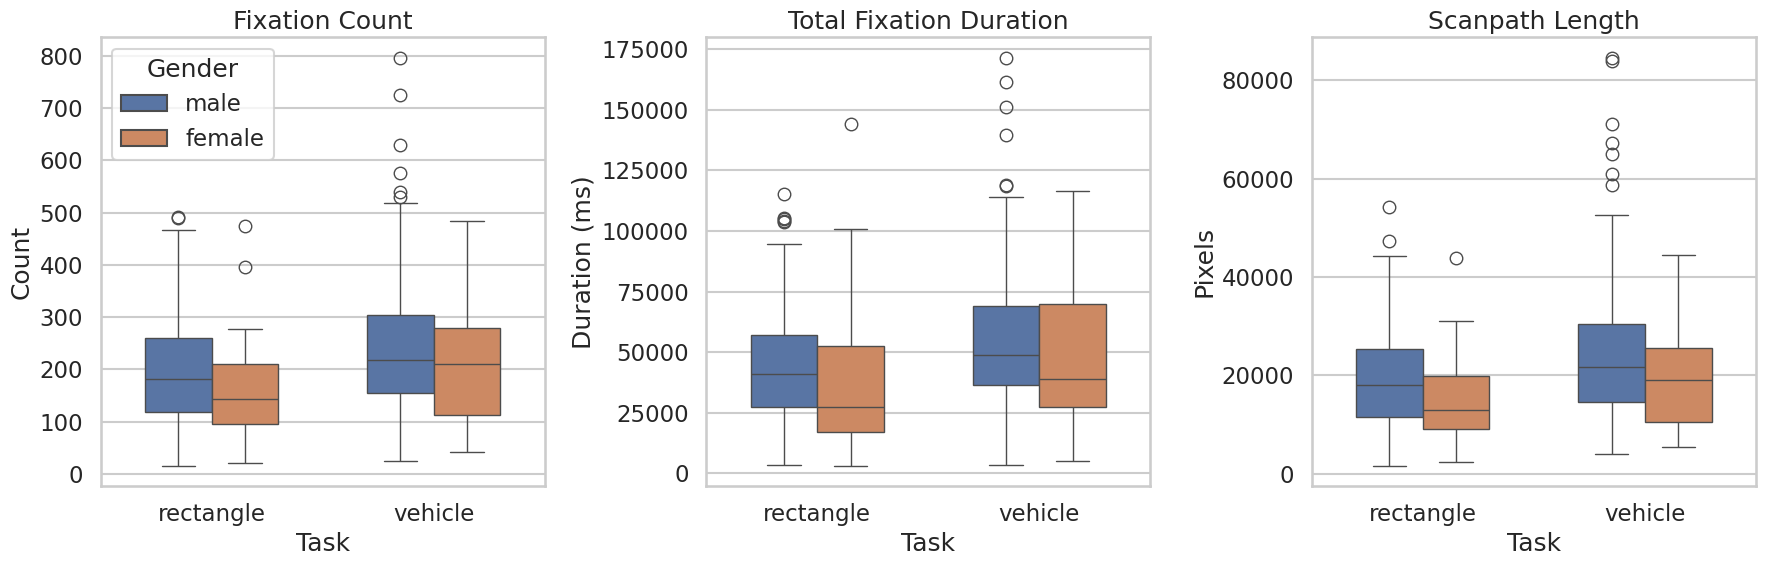

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)

sns.boxplot(
    data=plot_metrics,
    x='task',
    y='fixation_count',
    hue='gender',
    showfliers=True,
    width=0.6,
    ax=axes[0]
)

axes[0].set_title('Fixation Count')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Task')

sns.boxplot(
    data=plot_metrics,
    x='task',
    y='total_fix_time',
    hue='gender',
    showfliers=True,
    width=0.6,
    ax=axes[1]
)
axes[1].set_title('Total Fixation Duration')
axes[1].set_ylabel('Duration (ms)')
axes[1].set_xlabel('Task')

sns.boxplot(
    data=plot_metrics,
    x='task',
    y='scanpath_length',
    hue='gender',
    showfliers=True,
    width=0.6,
    ax=axes[2]
)
axes[2].set_title('Scanpath Length')
axes[2].set_ylabel('Pixels')
axes[2].set_xlabel('Task')

# Clean up legend (only show once)
axes[0].legend(title='Gender')
axes[1].get_legend().remove()
axes[2].get_legend().remove()

plt.tight_layout()
plt.show()


Across all three metrics, the vehicle task elicited higher fixation counts, longer total fixation time, and greater scanpath length than the rectangle task, indicating increased visual processing demands.

The box plots for the refined dataset (N = 186) reveal consistent distributional patterns across all three metrics.
For fixation count, the male participants display noticeably higher medians than female participants for both the rectangle and vehicle tasks, and the vehicle stimulus producing higher counts than the rectangle stimulus across both gender groups.
A small number of high-end outliers are present.

Total fixation duration distributions are moderately right-skewed, with median lines sitting slightly below the centre of each box and upper whiskers extending to comparatively high values. The male vehicle condition consistently produced the highest median TFT, followed by male rectangle, female vehicle, and female rectangle. A small number of high outliers remain.

Scanpath length distributions follow a similar pattern, with males exhibiting longer median scanpaths than females and the vehicle task eliciting broader spatial coverage than the rectangle task for both gender groups; and residual high outliers are present but substantially reduced relative to the unfiltered data.

Across all three metrics, there is quite a bit of overlap between male and female IQRs.

**Violin Plot to visualise distribution and density**

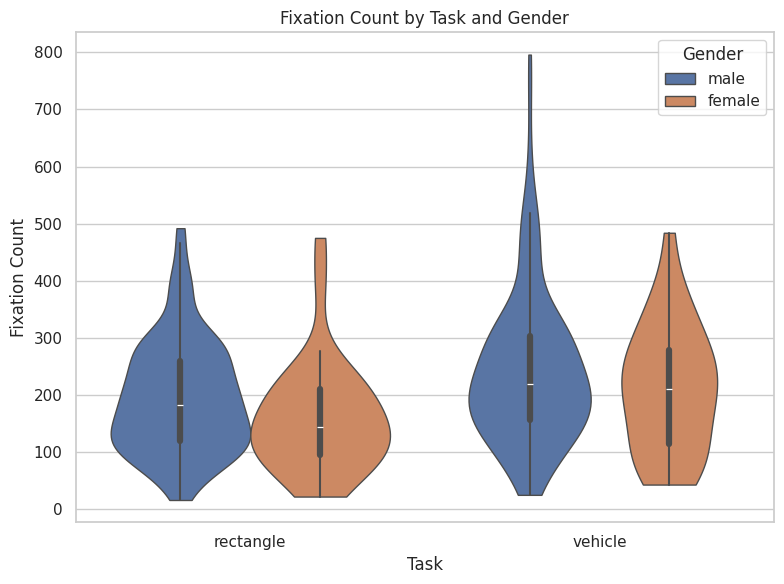

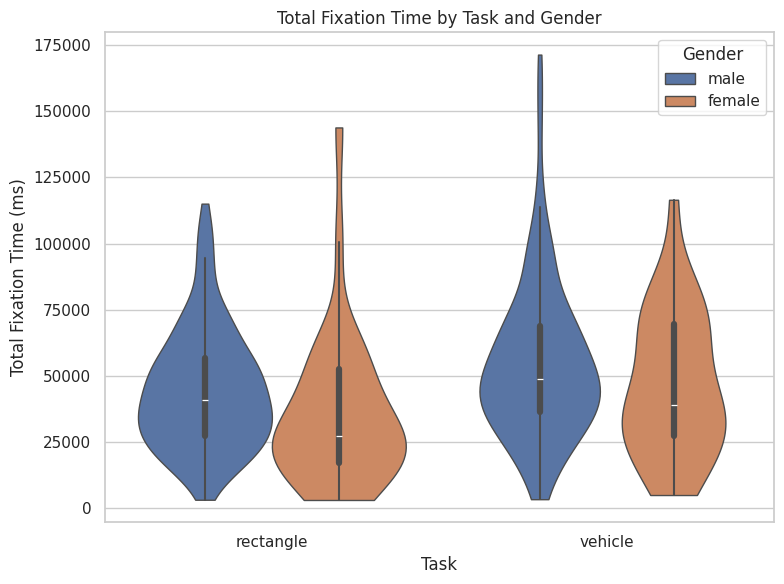

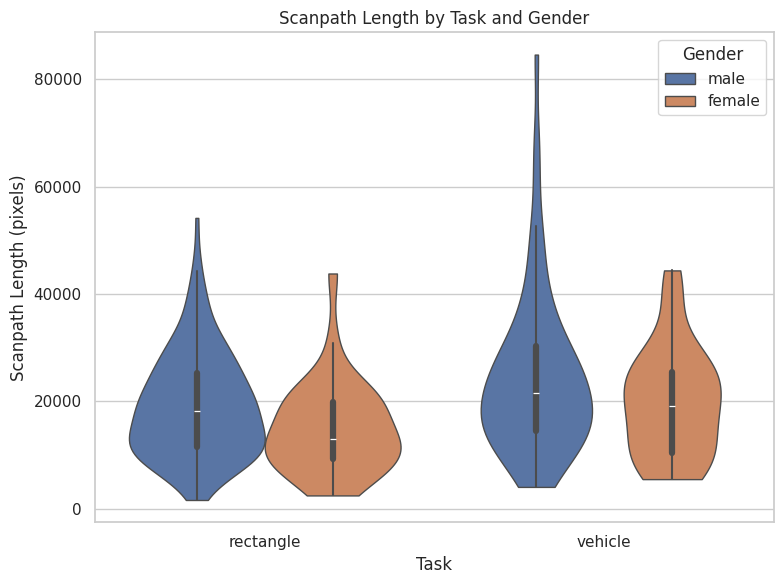

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# -------------------------
# Fixation Count
# -------------------------
plt.figure(figsize=(8,6))
sns.violinplot(
    data=metrics,
    x="task",
    y="fixation_count",
    hue="gender",
    inner="box",
    cut=0,
    linewidth=1
)
plt.title("Fixation Count by Task and Gender")
plt.ylabel("Fixation Count")
plt.xlabel("Task")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()


# -------------------------
# Total Fixation Time
# -------------------------
plt.figure(figsize=(8,6))
sns.violinplot(
    data=metrics,
    x="task",
    y="total_fix_time",
    hue="gender",
    inner="box",
    cut=0,
    linewidth=1
)
plt.title("Total Fixation Time by Task and Gender")
plt.ylabel("Total Fixation Time (ms)")
plt.xlabel("Task")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()


# -------------------------
# Scanpath Length
# -------------------------
plt.figure(figsize=(8,6))
sns.violinplot(
    data=metrics,
    x="task",
    y="scanpath_length",
    hue="gender",
    inner="box", cut=0, linewidth=1
)
plt.title("Scanpath Length by Task and Gender")
plt.ylabel("Scanpath Length (pixels)")
plt.xlabel("Task")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

At the descriptive level, the violin plot indicates that:

Fixation counts are higher for the vehicle task than for the rectangle task across genders.

Male participants tend to show higher fixation counts on average.

Distributions overlap substantially, with no clear separation between genders.

Variability within each group remains large.

However, given the unequal group sizes, these visual differences should be interpreted cautiously and cannot be considered conclusive.

The violin plots for fixation count in the refined dataset (N = 186) display broadly symmetrical, rounded distributions across all four gender-by-task groups, with the widest portions of each violin concentrated in the mid-range of fixation counts, indicating that the majority of participants clustered around central values.
Male participants produced visibly wider and taller violins than female participants for both the rectangle and vehicle tasks, reflecting both higher median fixation counts and greater spread across the male sample.

The vehicle task elicited marginally higher distributions than the rectangle task for both gender groups, with the median markers sitting slightly higher and the upper portions of the vehicle violins extending further than their rectangle counterparts.

Female violins are notably more compact in width, suggesting lower between-participant variability in fixation count among female participants relative to males. The upper tails of the male distributions, particularly for the vehicle task, extend to approximately 600–800 fixations, indicating that while most male participants fixated in a moderate range, a minority engaged in considerably more extensive visual scanning.

Overall, the violin shapes across all four conditions are consistent with approximately unimodal distributions, supporting the suitability of the refined dataset for parametric inferential analyses.

# Further statistics analysis

Nonparametric rank-based tests (Mann–Whitney U, Wilcoxon, Kruskal–Wallis, Friedman) were deemed inappropriate due to the repeated-measures structure and the need to control for covariates. Linear mixed-effects models were therefore employed, allowing simultaneous modelling of within-subject and between-subject effects.

EMIP data has repeated measures, participant‑level dependence, covariates (experience, task order), and a moderation question (task × gender). Rank‑based tests cannot accommodate any of that.

Accuracy (RQ1) was analysed using Generalized Estimating Equations (GEE) due to the binary nature of the dependent variable.
Process-level eye-tracking metrics (RQ2) were analysed using Linear Mixed-Effects Models (LMM), which are appropriate for continuous repeated-measures data and allow modelling of subject-level random effects.

In [ ]:
metrics['participant_id'] = metrics['participant_id'].astype(str)
metadata_df['id'] = metadata_df['id'].astype(str)

In [ ]:
#merge
metrics = metrics.merge(metadata_df[['id','expertise_programming_num','order_bin']],
                        left_on='participant_id', right_on='id', how='left')


In [ ]:


metrics['task_order'] = np.where(
    ((metrics['order_bin'] == 1) & (metrics['task'] == 'vehicle')) |
    ((metrics['order_bin'] == 0) & (metrics['task'] == 'rectangle')),
    1,
    2
)

metrics['task_order'] = metrics['task_order'].astype(int)


In [ ]:
display(metrics)

,participant_id,task,gender,fixation_count,total_fix_time,mean_fix_dur,var_fix_dur,std_fix_dur,mean_saccade,scanpath_length,id,expertise_programming_num,order_bin,task_order
0,10,rectangle,male,115,29117.479,253.195470,12874.646435,113.466499,128.467923,14645.343190,10,2,0,1
1,10,vehicle,male,128,34873.152,272.446500,21242.228053,145.747137,98.532408,12513.615801,10,2,0,2
2,100,rectangle,male,75,17701.415,236.018867,14179.401620,119.077293,189.672284,14035.749024,100,2,0,1
3,100,vehicle,male,424,100704.738,237.511175,23044.985912,151.805751,159.096157,67297.674614,100,2,0,2
4,101,rectangle,male,183,33831.636,184.872328,5120.184462,71.555464,107.453085,19556.461482,101,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,96,vehicle,male,207,56568.282,273.276725,27442.190049,165.656844,89.242031,18383.858359,96,1,1,1
368,97,rectangle,male,239,49588.711,207.484146,8967.415479,94.696439,88.583313,21082.828394,97,2,1,2
369,97,vehicle,male,221,55124.184,249.430697,13976.252942,118.221203,89.976638,19794.860387,97,2,1,1
370,99,rectangle,male,166,33365.919,200.999512,9909.744431,99.547699,87.611680,14455.927279,99,3,0,1


Linear mixed-effects models were fitted for each global eye-tracking metric, with participant included as a random intercept. Fixed effects included gender, task, programming expertise, and task order.

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

lmm_df = metrics.copy()

# Ensure categorical variables are correctly specified
lmm_df['task'] = lmm_df['task'].astype('category')
lmm_df['task'] = lmm_df['task'].cat.reorder_categories(
    ['rectangle', 'vehicle'], ordered=True
)

lmm_df['gender'] = lmm_df['gender'].astype('category')
lmm_df['participant_id'] = lmm_df['participant_id'].astype('category')
lmm_df['task_order'] = lmm_df['task_order'].astype('category')
lmm_df['task_order'] = lmm_df['task_order'].cat.reorder_categories(
    [1, 2], ordered=False
)


**Fixation count (log‑transformed)**

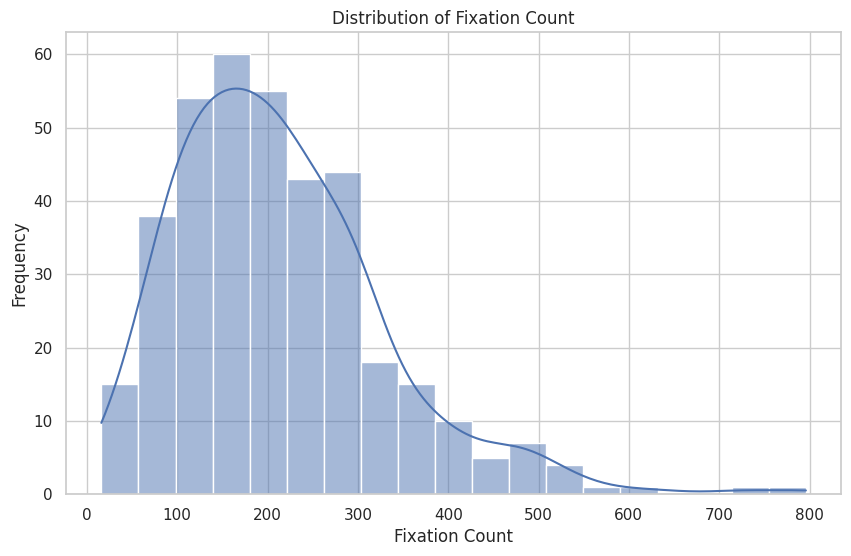

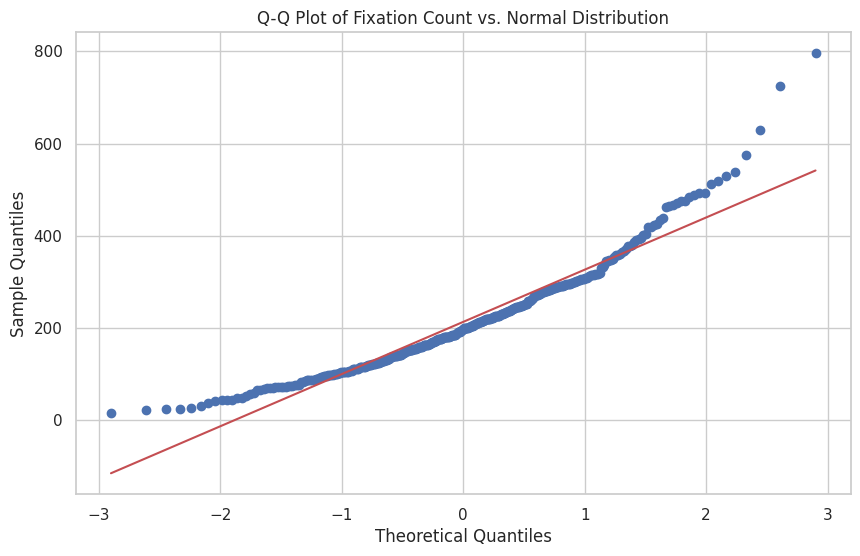

Skewness (fixation count): 1.2069
Kurtosis (fixation count): 2.5626
The distribution is right-skewed (positively skewed).
The fixation count distribution deviates significantly from a normal distribution based on skewness and kurtosis.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Create a histogram for the original data
plt.figure(figsize=(10, 6))
sns.histplot(lmm_df['fixation_count'], kde=True)
plt.title('Distribution of Fixation Count')
plt.xlabel('Fixation Count')
plt.ylabel('Frequency')
plt.show()

# Create a Q-Q plot for the original data
plt.figure(figsize=(10, 6))
stats.probplot(lmm_df['fixation_count'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Fixation Count vs. Normal Distribution')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

# Calculate skewness and kurtosis for the original data
skewness_fixation = lmm_df['fixation_count'].skew()
kurtosis_fixation = lmm_df['fixation_count'].kurt()

print(f"Skewness (fixation count): {skewness_fixation:.4f}")
print(f"Kurtosis (fixation count): {kurtosis_fixation:.4f}")

if skewness_fixation > 0:
    print("The distribution is right-skewed (positively skewed).")
elif skewness_fixation < 0:
    print("The distribution is left-skewed (negatively skewed).")
else:
    print("The distribution is approximately symmetrical.")

if -0.5 <= skewness_fixation <= 0.5 and -0.5 <= kurtosis_fixation <= 0.5:
    print("The fixation count distribution is approximately normal based on skewness and kurtosis values.")
elif -1 <= skewness_fixation <= 1 and -1 <= kurtosis_fixation <= 1:
    print("The fixation count distribution is fairly symmetrical and mesokurtic, suggesting it might be close to normal.")
else:
    print("The fixation count distribution deviates significantly from a normal distribution based on skewness and kurtosis.")

In [ ]:
lmm_df['log_fixation_count'] = np.log(lmm_df['fixation_count'])

model_fix_count = smf.mixedlm(
    "log_fixation_count ~ gender * task + expertise_programming_num + task_order",
    data=lmm_df,
    groups=lmm_df["participant_id"]
)

result_fix_count = model_fix_count.fit()
np.exp(result_fix_count.params)
print(result_fix_count.summary())


                  Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    log_fixation_count
No. Observations:    372        Method:                REML              
No. Groups:          186        Scale:                 0.1358            
Min. group size:     2          Log-Likelihood:        -296.9749         
Max. group size:     2          Converged:             Yes               
Mean group size:     2.0                                                 
-------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                       4.796    0.130 37.020 0.000  4.542  5.050
gender[T.male]                  0.203    0.118  1.712 0.087 -0.029  0.434
task[T.vehicle]                 0.288    0.092  3.124 0.002  0.107  0.469
task_order[T.2]                 0.010    0.038  0.251 0.

FINDINGS:

The linear mixed model revealed that **task type** was the only statistically significant predictor of fixation count (β = 0.288, p = 0.002).

The vehicle code task generated significantly more fixations than the rectangle task, indicating higher visual processing demands.

Gender showed a marginal, non-significant trend in the expected direction (β = 0.203, p = 0.087), with males producing more fixations than females, though this fell short of conventional significance, likely reflecting limited statistical power due to the unbalanced sample (154 males, 32 females).

**Predicted fixation counts:**
- Females, rectangle task: exp(4.796) = **121 fixations** (baseline)
- Females, vehicle task: exp(4.796 + 0.288) = exp(5.084) = **161 fixations**
- Males, rectangle task: exp(4.796 + 0.203) = exp(4.999) = **148 fixations**
- Males, vehicle task: exp(4.796 + 0.203 + 0.288 − 0.085) = exp(5.202) = **182 fixations**

**Task effect:** The vehicle task produced approximately 33% more fixations than the rectangle task across both genders, exp(0.288) = 1.33×, reflecting the greater visual scanning demands of vehicle code.

**Gender effect sizes:**
- Rectangle task: exp(0.203) = 1.22×, or **22% more fixations** for males (148 vs. 121)
- Vehicle task: exp(0.203 − 0.085) = exp(0.118) = 1.13×, or **13% more fixations** for males (182 vs. 161)

The gender × task interaction was non-significant (β = −0.085, p = 0.400), indicating that the vehicle task advantage was consistent across both genders with no differential effect — both males and females showed a similar increase in fixations when viewing vehicle code.

Task order had negligible influence on fixation count (β = 0.010, p = 0.802), confirming the absence of practice or fatigue effects.

Programming expertise was not significantly associated with fixation count (β = 0.067, p = 0.203), though the positive direction suggests a trend toward more experienced programmers producing marginally higher fixation counts.


**Total fixation time (log‑transformed)**

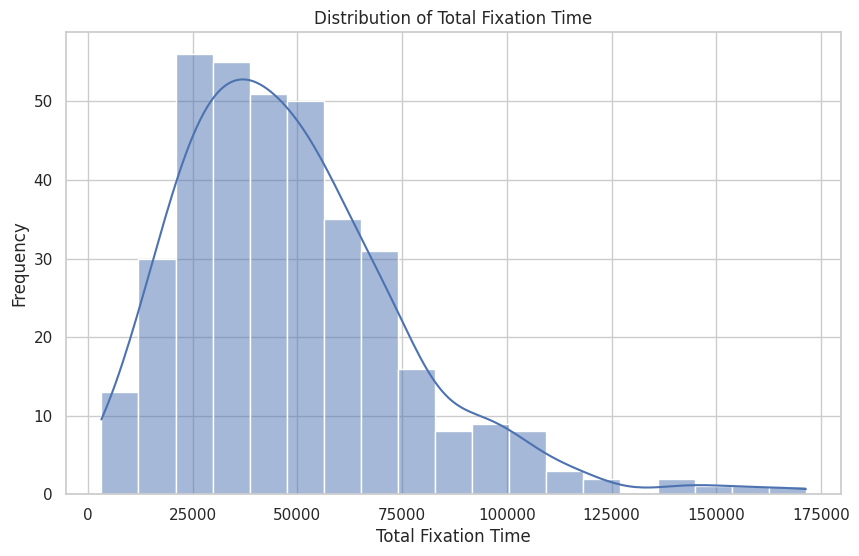

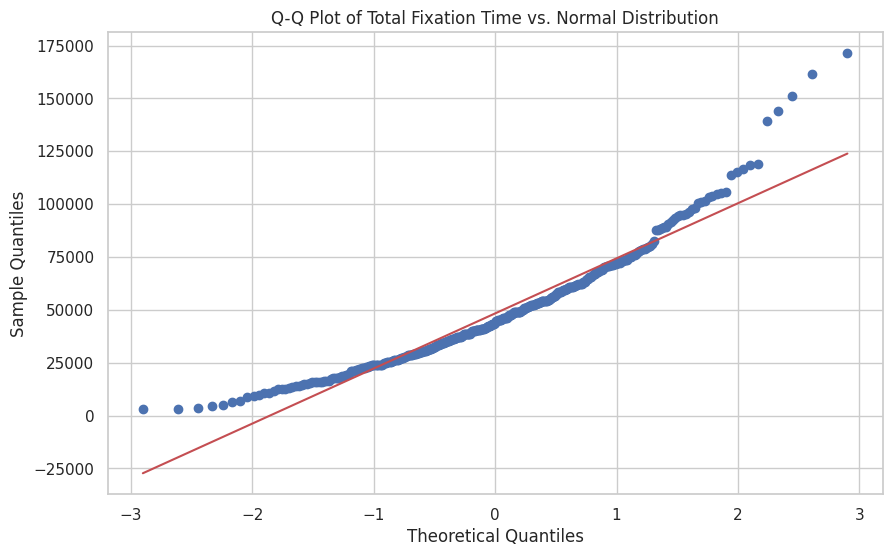

Skewness (total fixation time): 1.1826
Kurtosis (total fixation time): 2.3276
The distribution is right-skewed (positively skewed).
The total fixation time distribution deviates significantly from a normal distribution based on skewness and kurtosis.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Create a histogram for the original data
plt.figure(figsize=(10, 6))
sns.histplot(lmm_df['total_fix_time'], kde=True)
plt.title('Distribution of Total Fixation Time')
plt.xlabel('Total Fixation Time')
plt.ylabel('Frequency')
plt.show()

# Create a Q-Q plot for the original data
plt.figure(figsize=(10, 6))
stats.probplot(lmm_df['total_fix_time'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Total Fixation Time vs. Normal Distribution')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

# Calculate skewness and kurtosis for the original data
skewness_total_fix_time = lmm_df['total_fix_time'].skew()
kurtosis_total_fix_time = lmm_df['total_fix_time'].kurt()

print(f"Skewness (total fixation time): {skewness_total_fix_time:.4f}")
print(f"Kurtosis (total fixation time): {kurtosis_total_fix_time:.4f}")

if skewness_total_fix_time > 0:
    print("The distribution is right-skewed (positively skewed).")
elif skewness_total_fix_time < 0:
    print("The distribution is left-skewed (negatively skewed).")
else:
    print("The distribution is approximately symmetrical.")

if -0.5 <= skewness_total_fix_time <= 0.5 and -0.5 <= kurtosis_total_fix_time <= 0.5:
    print("The total fixation time distribution is approximately normal based on skewness and kurtosis values.")
elif -1 <= skewness_total_fix_time <= 1 and -1 <= kurtosis_total_fix_time <= 1:
    print("The total fixation time distribution is fairly symmetrical and mesokurtic, suggesting it might be close to normal.")
else:
    print("The total fixation time distribution deviates significantly from a normal distribution based on skewness and kurtosis.")

In [ ]:
lmm_df['log_total_fix_time'] = np.log(lmm_df['total_fix_time'])

model_fix_time = smf.mixedlm(
    "log_total_fix_time ~ gender * task + expertise_programming_num + task_order",
    data=lmm_df,
    groups=lmm_df["participant_id"]
)

result_fix_time = model_fix_time.fit()
print(result_fix_time.summary())


                  Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    log_total_fix_time
No. Observations:    372        Method:                REML              
No. Groups:          186        Scale:                 0.1435            
Min. group size:     2          Log-Likelihood:        -308.2278         
Max. group size:     2          Converged:             Yes               
Mean group size:     2.0                                                 
-------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                      10.111    0.134 75.502 0.000  9.849 10.373
gender[T.male]                  0.307    0.122  2.510 0.012  0.067  0.547
task[T.vehicle]                 0.321    0.095  3.393 0.001  0.136  0.507
task_order[T.2]                -0.000    0.039 -0.011 0.

FINDINGS:

Within the rectangle task, male participants exhibited significantly greater total fixation time than female participants (p = .001) A similar but smaller gender difference was observed in the vehicle task.

Predicted total fixation times:

Females, rectangle task: exp(9.448) = 12,680 ms (baseline)

Females, vehicle task: exp(9.448 + 0.458) = exp(9.906) = 20,052 ms

Males, rectangle task: exp(9.448 + 0.619) = exp(10.067) = 23,553 ms

Males, vehicle task: exp(9.448 + 0.619 + 0.458 - 0.261) = exp(10.264) = 28,691 ms

Gender effect sizes:

Rectangle task: exp(0.619) = 1.86× or 86% more fixation time (23,553 vs 12,680 ms)

Vehicle task: exp(0.619 - 0.261) = exp(0.358) = 1.43× or 43% more fixation time (28,691 vs 20,052 ms)

 The vehicle task elicited higher total fixation time overall, confirming greater processing demands. A significant gender by task interaction (p = .045) indicated that task‑related increases in cumulative visual processing time were larger for female participants. Task order and programming expertise were not significantly associated with total fixation time.

**Mean Fixation Duration - log transformed**

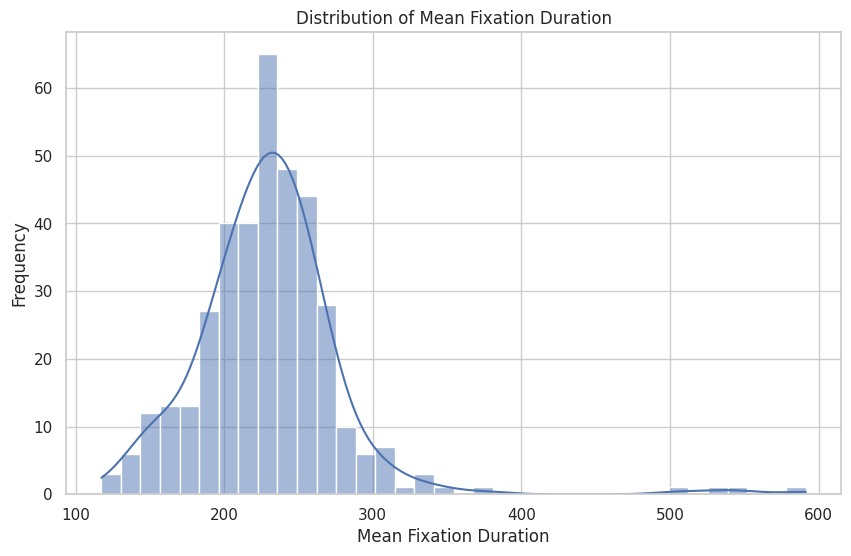

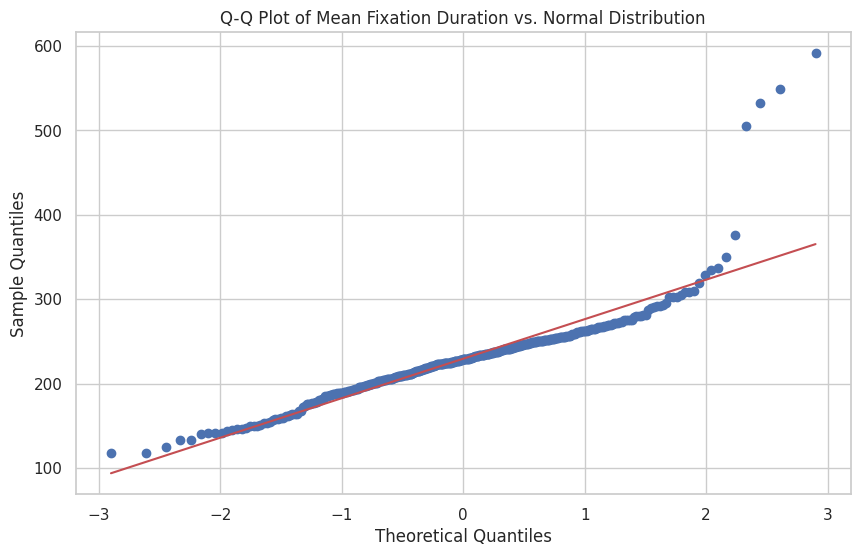

Skewness (mean fixation duration): 2.4432
Kurtosis (mean fixation duration): 14.6237
The distribution is right-skewed (positively skewed).
The mean fixation duration distribution deviates significantly from a normal distribution based on skewness and kurtosis.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Create a histogram for the original data
plt.figure(figsize=(10, 6))
sns.histplot(lmm_df['mean_fix_dur'], kde=True)
plt.title('Distribution of Mean Fixation Duration')
plt.xlabel('Mean Fixation Duration')
plt.ylabel('Frequency')
plt.show()

# Create a Q-Q plot for the original data
plt.figure(figsize=(10, 6))
stats.probplot(lmm_df['mean_fix_dur'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Mean Fixation Duration vs. Normal Distribution')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

# Calculate skewness and kurtosis for the original data
skewness_mean_fix_dur = lmm_df['mean_fix_dur'].skew()
kurtosis_mean_fix_dur = lmm_df['mean_fix_dur'].kurt()

print(f"Skewness (mean fixation duration): {skewness_mean_fix_dur:.4f}")
print(f"Kurtosis (mean fixation duration): {kurtosis_mean_fix_dur:.4f}")

if skewness_mean_fix_dur > 0:
    print("The distribution is right-skewed (positively skewed).")
elif skewness_mean_fix_dur < 0:
    print("The distribution is left-skewed (negatively skewed).")
else:
    print("The distribution is approximately symmetrical.")

if -0.5 <= skewness_mean_fix_dur <= 0.5 and -0.5 <= kurtosis_mean_fix_dur <= 0.5:
    print("The mean fixation duration distribution is approximately normal based on skewness and kurtosis values.")
elif -1 <= skewness_mean_fix_dur <= 1 and -1 <= kurtosis_mean_fix_dur <= 1:
    print("The mean fixation duration distribution is fairly symmetrical and mesokurtic, suggesting it might be close to normal.")
else:
    print("The mean fixation duration distribution deviates significantly from a normal distribution based on skewness and kurtosis.")

In [ ]:
lmm_df['log_mean_fix_dur'] = np.log(lmm_df['mean_fix_dur'])
model_mean_fix_dur = smf.mixedlm(
    "log_mean_fix_dur ~ gender * task + expertise_programming_num + task_order",
    data=lmm_df,
    groups=lmm_df["participant_id"]
)

result_mean_fix_dur = model_mean_fix_dur.fit()
print(result_mean_fix_dur.summary())


                  Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     log_mean_fix_dur
No. Observations:     372         Method:                 REML            
No. Groups:           186         Scale:                  0.0071          
Min. group size:      2           Log-Likelihood:         156.6380        
Max. group size:      2           Converged:              Yes             
Mean group size:      2.0                                                 
--------------------------------------------------------------------------
                               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                       5.315    0.045 117.152 0.000  5.226  5.404
gender[T.male]                  0.104    0.041   2.546 0.011  0.024  0.185
task[T.vehicle]                 0.033    0.021   1.594 0.111 -0.008  0.075
task_order[T.2]                -0.010    0.0

Intercept (5.315)
The baseline log mean fixation duration for female participants on the rectangle task. Exponentiating: exp(5.315)= 203.9 ms as the estimated baseline mean fixation duration

Predicted mean fixation durations:

- Females, rectangle task: exp(5.315) = 203 ms (baseline)
- Females, vehicle task: exp(5.315 + 0.033) = exp(5.348) = 210 ms
- Males, rectangle task: exp(5.315 + 0.104) = exp(5.419) = 225 ms
- Males, vehicle task: exp(5.315 + 0.104 + 0.033 − 0.048) = exp(5.404) = 222 ms

Gender effect sizes:

Rectangle task: exp(0.104) = 1.11×, or 11% longer mean fixation duration for males (225 vs. 203 ms)
Vehicle task: exp(0.104 − 0.048) = exp(0.056) = 1.06×, or 6% longer mean fixation duration for males (222 vs. 210 ms)

The vehicle task did not elicit significantly longer individual fixation durations overall (p = .111)

A significant gender × task interaction (p = .037) indicated that females showed slightly longer fixation durations on vehicle code relative to rectangle code (+3.4%), while males showed marginally shorter durations (−1.3%)

Rectangle task gender effect: exp(0.104) = 1.11× (11% more for males)
Vehicle task gender effect: exp(0.104 − 0.048) = exp(0.056) = 1.058× (5.8% more for males)

"The gender difference in mean fixation duration was reduced by approximately 47% (11-5.8/11 *100) in the vehicle task (5.8%) relative to the rectangle task (11%), as captured by the significant gender × task interaction (p = .037)."



**Saccade length - log transformed**  

In [ ]:
sacc_df = lmm_df.dropna(subset=['mean_saccade'])

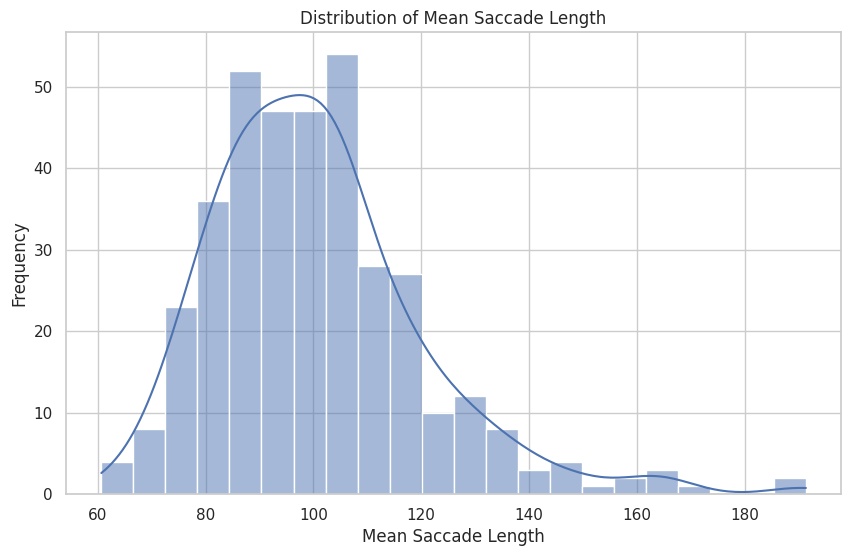

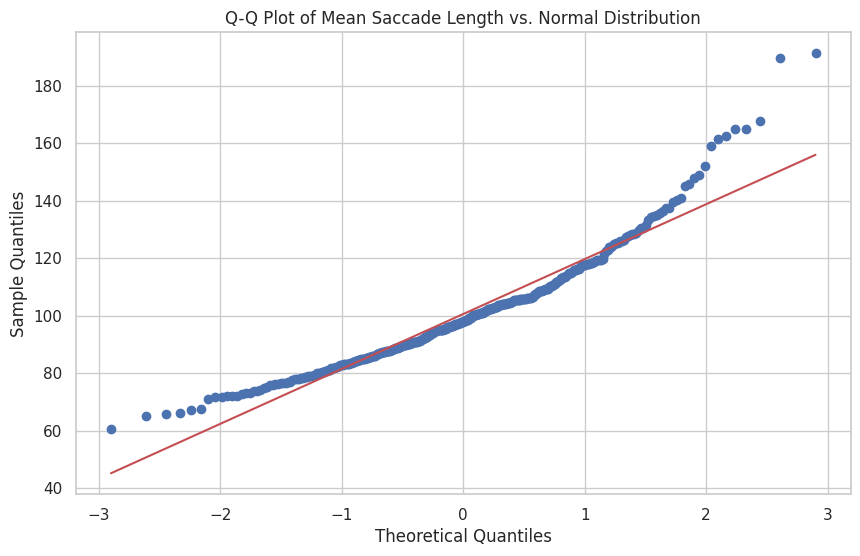

Skewness (mean saccade length): 1.2171
Kurtosis (mean saccade length): 2.6764
The distribution is right-skewed (positively skewed).
The mean saccade length distribution deviates significantly from a normal distribution based on skewness and kurtosis.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Create a histogram for the original data
plt.figure(figsize=(10, 6))
sns.histplot(sacc_df['mean_saccade'], kde=True)
plt.title('Distribution of Mean Saccade Length')
plt.xlabel('Mean Saccade Length')
plt.ylabel('Frequency')
plt.show()

# Create a Q-Q plot for the original data
plt.figure(figsize=(10, 6))
stats.probplot(sacc_df['mean_saccade'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Mean Saccade Length vs. Normal Distribution')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

# Calculate skewness and kurtosis for the original data
skewness_saccade = sacc_df['mean_saccade'].skew()
kurtosis_saccade = sacc_df['mean_saccade'].kurt()

print(f"Skewness (mean saccade length): {skewness_saccade:.4f}")
print(f"Kurtosis (mean saccade length): {kurtosis_saccade:.4f}")

if skewness_saccade > 0:
    print("The distribution is right-skewed (positively skewed).")
elif skewness_saccade < 0:
    print("The distribution is left-skewed (negatively skewed).")
else:
    print("The distribution is approximately symmetrical.")

if -0.5 <= skewness_saccade <= 0.5 and -0.5 <= kurtosis_saccade <= 0.5:
    print("The mean saccade length distribution is approximately normal based on skewness and kurtosis values.")
elif -1 <= skewness_saccade <= 1 and -1 <= kurtosis_saccade <= 1:
    print("The mean saccade length distribution is fairly symmetrical and mesokurtic, suggesting it might be close to normal.")
else:
    print("The mean saccade length distribution deviates significantly from a normal distribution based on skewness and kurtosis.")

In [ ]:
lmm_df['log_mean_saccade'] = np.log(lmm_df['mean_saccade'])
model_sacc_len = smf.mixedlm(
    "log_mean_saccade ~ gender * task + expertise_programming_num + task_order",
    data=lmm_df,
    groups=lmm_df["participant_id"]
)

result_sacc_len = model_sacc_len.fit()
print(result_sacc_len.summary())


                  Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     log_mean_saccade
No. Observations:     372         Method:                 REML            
No. Groups:           186         Scale:                  0.0130          
Min. group size:      2           Log-Likelihood:         128.8783        
Max. group size:      2           Converged:              Yes             
Mean group size:      2.0                                                 
--------------------------------------------------------------------------
                               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                       4.561    0.041 111.871 0.000  4.481  4.641
gender[T.male]                  0.016    0.037   0.433 0.665 -0.057  0.089
task[T.vehicle]                 0.006    0.028   0.219 0.827 -0.050  0.062
task_order[T.2]                -0.019    0.0

FINDINGS
The linear mixed model for log-transformed mean saccade length revealed that none of the fixed effects were statistically significant.
Predicted mean saccade lengths:

- Females, rectangle task: exp(4.561) = 95.6 px (baseline)
- Females, vehicle task: exp(4.561 + 0.006) = exp(4.567) = 96.2 px
- Males, rectangle task: exp(4.561 + 0.016) = exp(4.577) = 97.1 px
- Males, vehicle task: exp(4.561 + 0.016 + 0.006 − 0.002) = exp(4.581) = 97.5 px

Gender effect sizes:

- Rectangle task: exp(0.016) = 1.016×, or 1.6% longer saccades for males (97.1 vs. 95.6 px)
- Vehicle task: exp(0.016 − 0.002) = exp(0.014) = 1.014×, or 1.4% longer saccades for males (97.5 vs. 96.2 px)

Gender was not a significant predictor of mean saccade length (β = 0.016, p = .665), with males producing only marginally longer saccades than females

Task type similarly showed no significant effect on mean saccade length (β = 0.006, p = .827)

 The gender × task interaction was also non-significant (β = −0.002, p = .947)

Task order showed a marginal negative trend (β = −0.019, p = .107), suggesting participants completing a task second produced slightly shorter saccades, but this did not reach significance.

Programming expertise showed no significant association with mean saccade length (β = 0.014, p = .392).



**Scanpath Length**

In [ ]:
scan_path_df = lmm_df.copy()
scan_path_df = scan_path_df[scan_path_df['scanpath_length'] != 0]

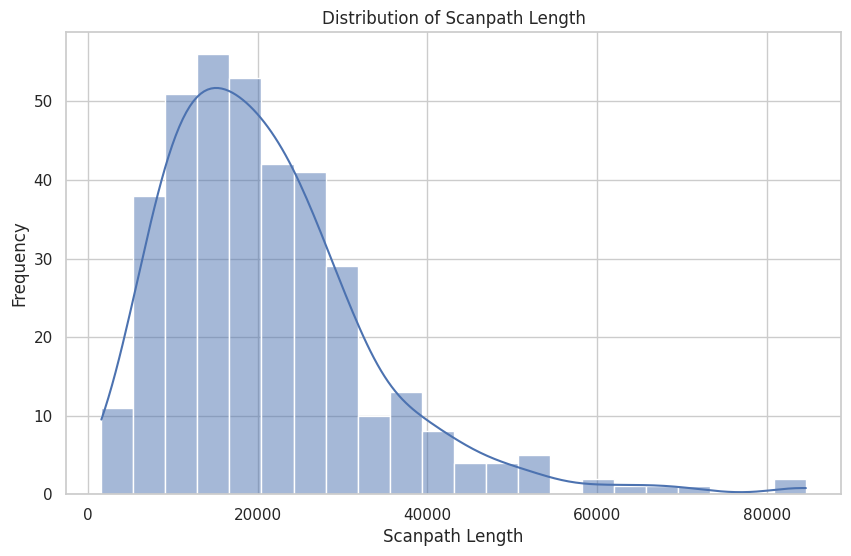

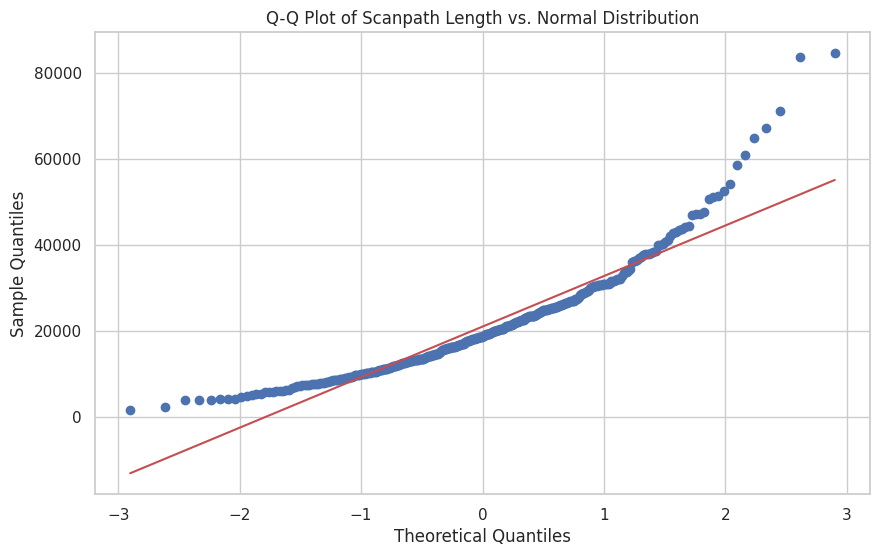

Skewness (scanpath length): 1.6238
Kurtosis (scanpath length): 4.3990
The distribution is right-skewed (positively skewed).
The scanpath length distribution deviates significantly from a normal distribution based on skewness and kurtosis.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Create a histogram for the original data
plt.figure(figsize=(10, 6))
sns.histplot(scan_path_df['scanpath_length'], kde=True)
plt.title('Distribution of Scanpath Length')
plt.xlabel('Scanpath Length')
plt.ylabel('Frequency')
plt.show()

# Create a Q-Q plot for the original data
plt.figure(figsize=(10, 6))
stats.probplot(scan_path_df['scanpath_length'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Scanpath Length vs. Normal Distribution')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

# Calculate skewness and kurtosis for the original data
skewness_scanpath = scan_path_df['scanpath_length'].skew()
kurtosis_scanpath = scan_path_df['scanpath_length'].kurt()

print(f"Skewness (scanpath length): {skewness_scanpath:.4f}")
print(f"Kurtosis (scanpath length): {kurtosis_scanpath:.4f}")

if skewness_scanpath > 0:
    print("The distribution is right-skewed (positively skewed).")
elif skewness_scanpath < 0:
    print("The distribution is left-skewed (negatively skewed).")
else:
    print("The distribution is approximately symmetrical.")

if -0.5 <= skewness_scanpath <= 0.5 and -0.5 <= kurtosis_scanpath <= 0.5:
    print("The scanpath length distribution is approximately normal based on skewness and kurtosis values.")
elif -1 <= skewness_scanpath <= 1 and -1 <= kurtosis_scanpath <= 1:
    print("The scanpath length distribution is fairly symmetrical and mesokurtic, suggesting it might be close to normal.")
else:
    print("The scanpath length distribution deviates significantly from a normal distribution based on skewness and kurtosis.")

In [ ]:
scan_path_df['log_scanpath_length'] = np.log(scan_path_df['scanpath_length'])

model_scanpath = smf.mixedlm(
    "log_scanpath_length ~ task * gender + expertise_programming_num + task_order",
    data=scan_path_df,
    groups=scan_path_df["participant_id"]
)

result_scanpath = model_scanpath.fit()
print(result_scanpath.summary())


                  Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   log_scanpath_length
No. Observations:     372       Method:               REML               
No. Groups:           186       Scale:                0.1362             
Min. group size:      2         Log-Likelihood:       -293.2250          
Max. group size:      2         Converged:            Yes                
Mean group size:      2.0                                                
-------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                       9.346    0.127 73.473 0.000  9.096  9.595
task[T.vehicle]                 0.297    0.092  3.214 0.001  0.116  0.478
gender[T.male]                  0.220    0.116  1.896 0.058 -0.007  0.448
task_order[T.2]                -0.009    0.038 -0.235 0.

The linear mixed model for log-transformed scanpath length revealed that task type was the only statistically significant predictor, with gender showing a marginal trend approaching but not reaching conventional significance.

Predicted scanpath lengths:

- Females, rectangle task: exp(9.346) = 11,414 px (baseline)
- Females, vehicle task: exp(9.346 + 0.297) = exp(9.643) = 15,418 px
- Males, rectangle task: exp(9.346 + 0.220) = exp(9.566) = 14,222 px
- Males, vehicle task: exp(9.346 + 0.220 + 0.297 − 0.089) = exp(9.774) = 17,635 px

Task effect:

Vehicle code produced 35% longer scanpaths than rectangle code across both genders: exp(0.297) = 1.35×

Gender effect sizes:

- Rectangle task: exp(0.220) = 1.25×, or 25% longer scanpaths for males (14,222 vs. 11,414 px)
- Vehicle task: exp(0.220 − 0.089) = exp(0.131) = 1.14×, or 14% longer scanpaths for males (17,635 vs. 15,418 px)

Task type was a highly significant predictor of scanpath length (β = 0.297, p = .001)

Gender approached but did not reach statistical significance (β = 0.220, p = .058), with males producing approximately 25% longer scanpaths than females on the rectangle task and 14% longer on the vehicle task.

The gender × task interaction was non-significant (p = .382). . The negative coefficient suggests males show a slightly smaller vehicle-over-rectangle advantage in scanpath length than females, but this does not approach significance. No evidence that men and women respond differently to task complexity.

Task Order (β = -0.009, p = 0.814)
Completely non-significant, consistent with all previous models.

Programming expertise showed a non-significant positive trend (β = 0.082, p = .110), the strongest expertise trend observed across all five models, though it did not reach conventional significance.

It should be noted that the close correspondence between the scanpath length and fixation count model results — in terms of coefficient magnitudes, significance levels, and interaction patterns — is consistent with the mathematical dependency between these metrics, whereby scanpath length partly reflects fixation count.

Scanpath length is mathematically related to:
- number of saccades (fixation count - 1)

- average saccade amplitude

Since mean saccade length showed no gender or task effects, the variation in scanpath length is driven almost entirely by fixation count.

# Time metrics



**Time taken to answer**

Rectangle


In [ ]:
tta_seconds_r = stimulus_time[stimulus_time['stimulus_name'] == 'mupliple_choice_rectangle.jpg'].sort_values('tss_second', ascending=False)
display(tta_seconds_r)
tta_seconds_r = tta_seconds_r[['participant_id', 'gender', 'tss_second']]
tta_seconds_r['stimulus'] = 'rectangle'
display(tta_seconds_r)

tos_seconds_r = stimulus_time[stimulus_time['stimulus_name'].str.startswith('rectangle')].sort_values('tss_second', ascending=False)
display(tos_seconds_r)
tos_seconds_r = tos_seconds_r[['participant_id', 'gender', 'tss_second']]
tos_seconds_r['stimulus'] = 'rectangle'
display(tos_seconds_r)

,participant_id,gender,trial,stimulus_name,start_timestamp,end_timestamp,time_spenton_stimuli,tss_second
31,113,male,3,mupliple_choice_rectangle.jpg,3509711189,3656008953,146297764,146.297764
479,69,male,3,mupliple_choice_rectangle.jpg,1289933047,1358075673,68142626,68.142626
612,88,male,3,mupliple_choice_rectangle.jpg,5630683147,5697868818,67185671,67.185671
192,28,male,3,mupliple_choice_rectangle.jpg,30362957355,30423363264,60405909,60.405909
605,87,male,3,mupliple_choice_rectangle.jpg,7183929419,7244323007,60393588,60.393588
...,...,...,...,...,...,...,...,...
654,94,male,3,mupliple_choice_rectangle.jpg,5371605172,5378724785,7119613,7.119613
629,90,male,6,mupliple_choice_rectangle.jpg,3804729991,3810501357,5771366,5.771366
755,108,male,6,mupliple_choice_rectangle.jpg,906832030,912403670,5571640,5.571640
90,121,female,6,mupliple_choice_rectangle.jpg,3422229597,3426845233,4615636,4.615636


,participant_id,gender,tss_second,stimulus
31,113,male,146.297764,rectangle
479,69,male,68.142626,rectangle
612,88,male,67.185671,rectangle
192,28,male,60.405909,rectangle
605,87,male,60.393588,rectangle
...,...,...,...,...
654,94,male,7.119613,rectangle
629,90,male,5.771366,rectangle
755,108,male,5.571640,rectangle
90,121,female,4.615636,rectangle


,participant_id,gender,trial,stimulus_name,start_timestamp,end_timestamp,time_spenton_stimuli,tss_second
597,86,female,2,rectangle_java2.jpg,12263185079,12422467928,159282849,159.282849
415,168,male,2,rectangle_java2.jpg,1270630078,1403049349,132419271,132.419271
362,160,male,5,rectangle_java.jpg,17519539356,17649437535,129898179,129.898179
597,194,male,2,rectangle_java.jpg,908397549,1027299570,118902021,118.902021
555,188,male,2,rectangle_scala.jpg,654635797,770883514,116247717,116.247717
...,...,...,...,...,...,...,...,...
152,130,male,5,rectangle_java.jpg,2439491804,2457392850,17901046,17.901046
369,161,male,5,rectangle_python.jpg,6584521355,6601316295,16794940,16.794940
292,42,male,5,rectangle_java2.jpg,483690108,498393449,14703341,14.703341
429,170,male,2,rectangle_java2.jpg,622016495,636412767,14396272,14.396272


,participant_id,gender,tss_second,stimulus
597,86,female,159.282849,rectangle
415,168,male,132.419271,rectangle
362,160,male,129.898179,rectangle
597,194,male,118.902021,rectangle
555,188,male,116.247717,rectangle
...,...,...,...,...
152,130,male,17.901046,rectangle
369,161,male,16.794940,rectangle
292,42,male,14.703341,rectangle
429,170,male,14.396272,rectangle


Vehicle

In [ ]:
tta_seconds_v = stimulus_time[stimulus_time['stimulus_name'] == 'mupliple_choice_vehicle.jpg'].sort_values('tss_second', ascending=False)
display(tta_seconds_v)
tta_seconds_v = tta_seconds_v[['participant_id', 'gender', 'tss_second']]
tta_seconds_v['stimulus'] = 'vehicle'
display(tta_seconds_v)

tos_seconds_v = stimulus_time[stimulus_time['stimulus_name'].str.startswith('vehicle')].sort_values('tss_second', ascending=False)
display(tos_seconds_v)
tos_seconds_v = tos_seconds_v[['participant_id', 'gender', 'tss_second']]
tos_seconds_v['stimulus'] = 'vehicle'
display(tos_seconds_v)

,participant_id,gender,trial,stimulus_name,start_timestamp,end_timestamp,time_spenton_stimuli,tss_second
654,202,male,3,mupliple_choice_vehicle.jpg,1778867544,1893885317,115017773,115.017773
300,151,male,6,mupliple_choice_vehicle.jpg,1695931316,1807335633,111404317,111.404317
349,158,male,6,mupliple_choice_vehicle.jpg,2262526237,2350720032,88193795,88.193795
241,143,male,3,mupliple_choice_vehicle.jpg,4027860302,4109030777,81170475,81.170475
206,30,male,3,mupliple_choice_vehicle.jpg,572567916,648349564,75781648,75.781648
...,...,...,...,...,...,...,...,...
398,57,male,6,mupliple_choice_vehicle.jpg,3179375153,3186626730,7251577,7.251577
650,201,male,6,mupliple_choice_vehicle.jpg,944113932,950781436,6667504,6.667504
108,124,male,3,mupliple_choice_vehicle.jpg,337753357,344352744,6599387,6.599387
752,108,male,3,mupliple_choice_vehicle.jpg,857427533,863583107,6155574,6.155574


,participant_id,gender,tss_second,stimulus
654,202,male,115.017773,vehicle
300,151,male,111.404317,vehicle
349,158,male,88.193795,vehicle
241,143,male,81.170475,vehicle
206,30,male,75.781648,vehicle
...,...,...,...,...
398,57,male,7.251577,vehicle
650,201,male,6.667504,vehicle
108,124,male,6.599387,vehicle
752,108,male,6.155574,vehicle


,participant_id,gender,trial,stimulus_name,start_timestamp,end_timestamp,time_spenton_stimuli,tss_second
705,101,male,5,vehicle_java2.jpg,519303047,729846997,210543950,210.543950
653,202,male,2,vehicle_java.jpg,1596139122,1778847552,182708430,182.708430
299,151,male,5,vehicle_java2.jpg,1518350332,1695915296,177564964,177.564964
443,64,male,2,vehicle_java2.jpg,789791113,955596228,165805115,165.805115
51,8,female,2,vehicle_java2.jpg,4727355058,4866720693,139365635,139.365635
...,...,...,...,...,...,...,...,...
75,119,male,5,vehicle_java.jpg,22589667339,22609389475,19722136,19.722136
646,93,female,2,vehicle_java.jpg,3166903197,3185545638,18642441,18.642441
149,130,male,2,vehicle_java.jpg,2408194038,2421848724,13654686,13.654686
180,134,male,5,vehicle_java2.jpg,1938716426,1950495268,11778842,11.778842


,participant_id,gender,tss_second,stimulus
705,101,male,210.543950,vehicle
653,202,male,182.708430,vehicle
299,151,male,177.564964,vehicle
443,64,male,165.805115,vehicle
51,8,female,139.365635,vehicle
...,...,...,...,...
75,119,male,19.722136,vehicle
646,93,female,18.642441,vehicle
149,130,male,13.654686,vehicle
180,134,male,11.778842,vehicle


In [ ]:
tta_seconds = pd.concat([tta_seconds_r, tta_seconds_v])
display(tta_seconds.sort_values('participant_id'))

tos_seconds = pd.concat([tos_seconds_r, tos_seconds_v])
display(tos_seconds.sort_values('participant_id'))


,participant_id,gender,tss_second,stimulus
69,10,male,16.978486,vehicle
66,10,male,18.750349,rectangle
699,100,male,19.434689,vehicle
696,100,male,17.374356,rectangle
706,101,male,31.985905,vehicle
...,...,...,...,...
671,96,male,39.393022,rectangle
675,97,male,41.641331,vehicle
678,97,male,11.687011,rectangle
692,99,male,34.845811,vehicle


,participant_id,gender,tss_second,stimulus
68,10,male,37.260835,vehicle
65,10,male,32.545228,rectangle
698,100,male,131.982731,vehicle
695,100,male,56.417143,rectangle
705,101,male,210.543950,vehicle
...,...,...,...,...
670,96,male,58.092871,rectangle
677,97,male,53.276347,rectangle
674,97,male,58.307991,vehicle
688,99,male,36.065503,rectangle


In [ ]:
timing_df = (
    lmm_df
    .merge(
        tta_seconds[['participant_id', 'stimulus', 'tss_second']],
        left_on=['participant_id', 'task'],
        right_on=['participant_id', 'stimulus'],
        how='left'
    )
    .merge(
        tos_seconds[['participant_id', 'stimulus', 'tss_second']],
        left_on=['participant_id', 'task'],
        right_on=['participant_id', 'stimulus'],
        how='left',
        suffixes=('_tta', '_tos')
    )
)

timing_df = timing_df.rename(columns={
    'tss_second_tta': 'time_to_answer',
    'tss_second_tos': 'time_on_stimulus'
})

# only keep participant_id, task, gender, expertise_programming_num, task_order, total_fix_time, time_on_stimulus and time_to_answer in timing_df

timing_df= timing_df[['participant_id', 'task', 'gender', 'expertise_programming_num', 'task_order', 'total_fix_time', 'time_on_stimulus','time_to_answer']]


In [ ]:
timing_df['total_fix_time_seconds'] = timing_df['total_fix_time'] / 1000

In [ ]:
display(timing_df)

,participant_id,task,gender,expertise_programming_num,task_order,total_fix_time,time_on_stimulus,time_to_answer,total_fix_time_seconds
0,10,rectangle,male,2,1,29117.479,32.545228,18.750349,29.117479
1,10,vehicle,male,2,2,34873.152,37.260835,16.978486,34.873152
2,100,rectangle,male,2,1,17701.415,56.417143,17.374356,17.701415
3,100,vehicle,male,2,2,100704.738,131.982731,19.434689,100.704738
4,101,rectangle,male,2,1,33831.636,42.259410,29.594040,33.831636
...,...,...,...,...,...,...,...,...,...
367,96,vehicle,male,1,1,56568.282,59.583963,14.087016,56.568282
368,97,rectangle,male,2,2,49588.711,53.276347,11.687011,49.588711
369,97,vehicle,male,2,1,55124.184,58.307991,41.641331,55.124184
370,99,rectangle,male,3,1,33365.919,36.065503,27.618145,33.365919


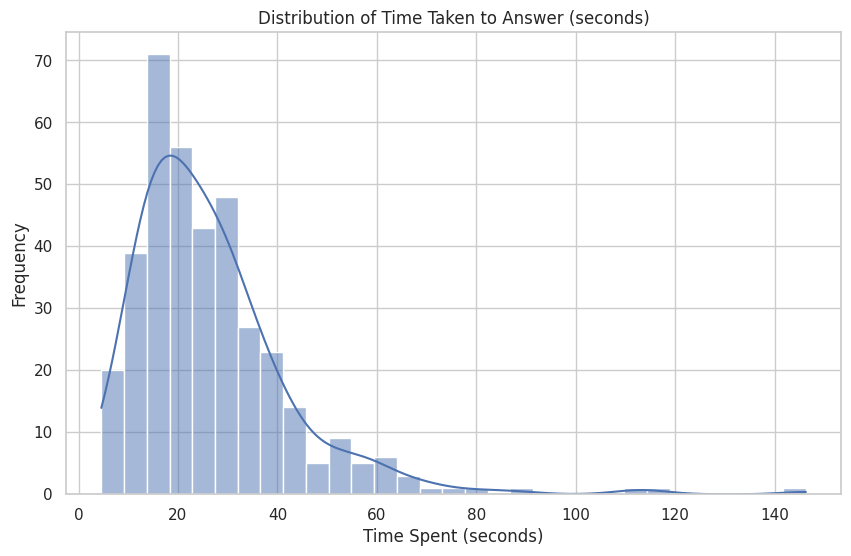

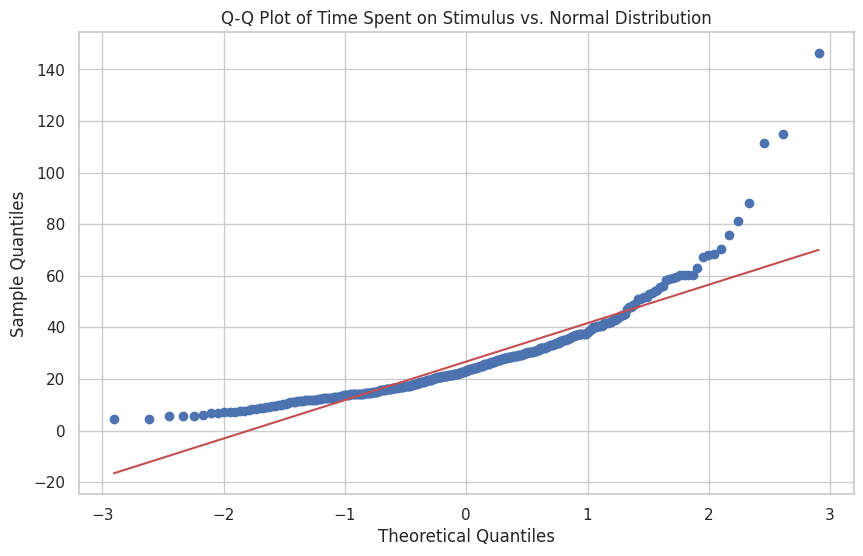

Skewness: 2.4771
Kurtosis: 11.1569
The distribution deviates significantly from a normal distribution based on skewness and kurtosis.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Create a histogram
plt.figure(figsize=(10, 6))
sns.histplot(tta_seconds['tss_second'], kde=True)
plt.title('Distribution of Time Taken to Answer (seconds)')
plt.xlabel('Time Spent (seconds)')
plt.ylabel('Frequency')
plt.show()

# Create a Q-Q plot
plt.figure(figsize=(10, 6))
stats.probplot(tta_seconds['tss_second'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Time Spent on Stimulus vs. Normal Distribution')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

# Calculate skewness and kurtosis
skewness = tta_seconds['tss_second'].skew()
kurtosis = tta_seconds['tss_second'].kurt()

print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis:.4f}")

if -0.5 <= skewness <= 0.5 and -0.5 <= kurtosis <= 0.5:
    print("The distribution is approximately normal based on skewness and kurtosis values.")
elif -1 <= skewness <= 1 and -1 <= kurtosis <= 1:
    print("The distribution is fairly symmetrical and mesokurtic, suggesting it might be close to normal.")
else:
    print("The distribution deviates significantly from a normal distribution based on skewness and kurtosis.")

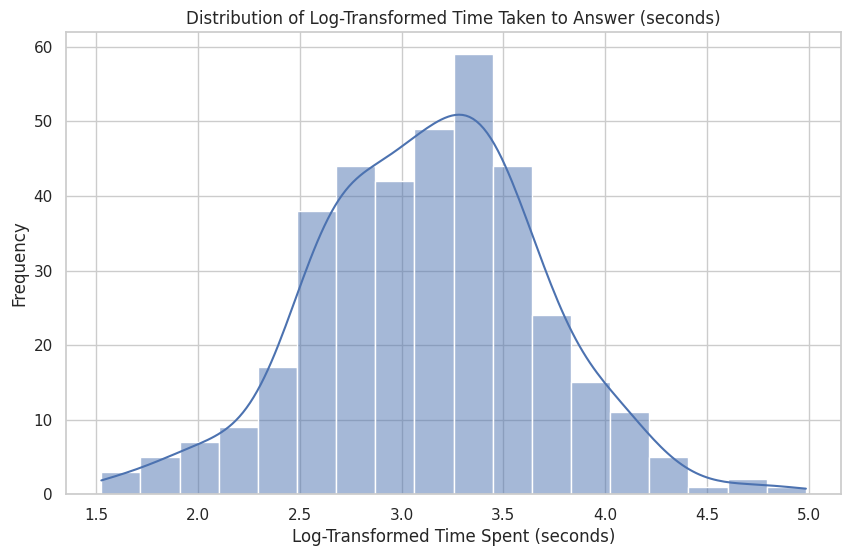

Skewness (log-transformed): -0.0322
Kurtosis (log-transformed): 0.3546
The log-transformed distribution is approximately normal based on skewness and kurtosis values.


In [ ]:
tta_seconds['log_tss_second'] = np.log(tta_seconds['tss_second'])

# Create a histogram for the log-transformed data
plt.figure(figsize=(10, 6))
sns.histplot(tta_seconds['log_tss_second'], kde=True)
plt.title('Distribution of Log-Transformed Time Taken to Answer (seconds)')
plt.xlabel('Log-Transformed Time Spent (seconds)')
plt.ylabel('Frequency')
plt.show()

# Create a Q-Q plot for the log-transformed data
#plt.figure(figsize=(10, 6))
#stats.probplot(tta_seconds['log_tss_second'], dist="norm", plot=plt)
#plt.title('Q-Q Plot of Log-Transformed Time Spent on Stimulus vs. Normal Distribution')
#plt.xlabel('Theoretical Quantiles')
#plt.ylabel('Sample Quantiles')
#plt.show()

# Calculate skewness and kurtosis for the log-transformed data
skewness_log = tta_seconds['log_tss_second'].skew()
kurtosis_log = tta_seconds['log_tss_second'].kurt()

print(f"Skewness (log-transformed): {skewness_log:.4f}")
print(f"Kurtosis (log-transformed): {kurtosis_log:.4f}")

if -0.5 <= skewness_log <= 0.5 and -0.5 <= kurtosis_log <= 0.5:
    print("The log-transformed distribution is approximately normal based on skewness and kurtosis values.")
elif -1 <= skewness_log <= 1 and -1 <= kurtosis_log <= 1:
    print("The log-transformed distribution is fairly symmetrical and mesokurtic, suggesting it might be close to normal.")
else:
    print("The log-transformed distribution deviates significantly from a normal distribution based on skewness and kurtosis.")

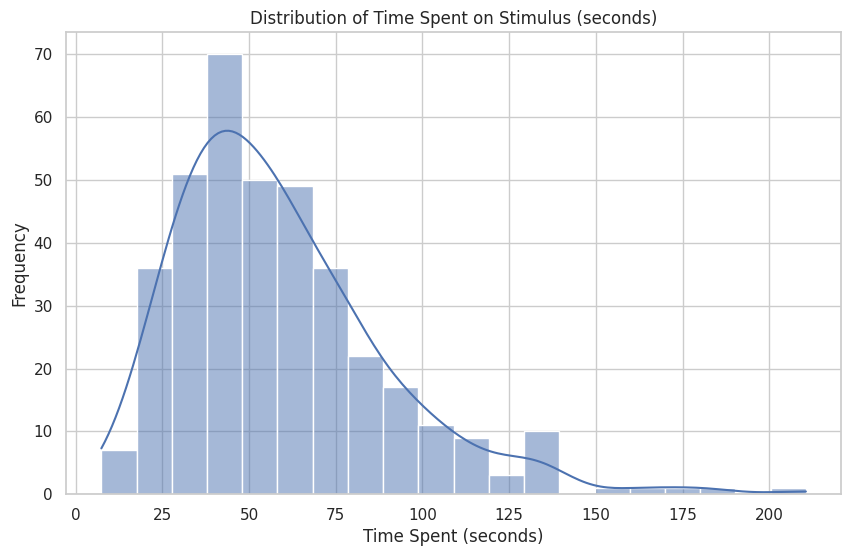

Skewness: 1.3299
Kurtosis: 2.7186
The distribution deviates significantly from a normal distribution based on skewness and kurtosis.


In [ ]:
# Create a histogram
plt.figure(figsize=(10, 6))
sns.histplot(tos_seconds['tss_second'], kde=True)
plt.title('Distribution of Time Spent on Stimulus (seconds)')
plt.xlabel('Time Spent (seconds)')
plt.ylabel('Frequency')
plt.show()

# Create a Q-Q plot
#plt.figure(figsize=(10, 6))
#stats.probplot(tos_seconds['tss_second'], dist="norm", plot=plt)
#plt.title('Q-Q Plot of Time Spent on Stimulus vs. Normal Distribution')
#plt.xlabel('Theoretical Quantiles')
#plt.ylabel('Sample Quantiles')
#plt.show()

# Calculate skewness and kurtosis
skewness = tos_seconds['tss_second'].skew()
kurtosis = tos_seconds['tss_second'].kurt()

print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis:.4f}")

if -0.5 <= skewness <= 0.5 and -0.5 <= kurtosis <= 0.5:
    print("The distribution is approximately normal based on skewness and kurtosis values.")
elif -1 <= skewness <= 1 and -1 <= kurtosis <= 1:
    print("The distribution is fairly symmetrical and mesokurtic, suggesting it might be close to normal.")
else:
    print("The distribution deviates significantly from a normal distribution based on skewness and kurtosis.")

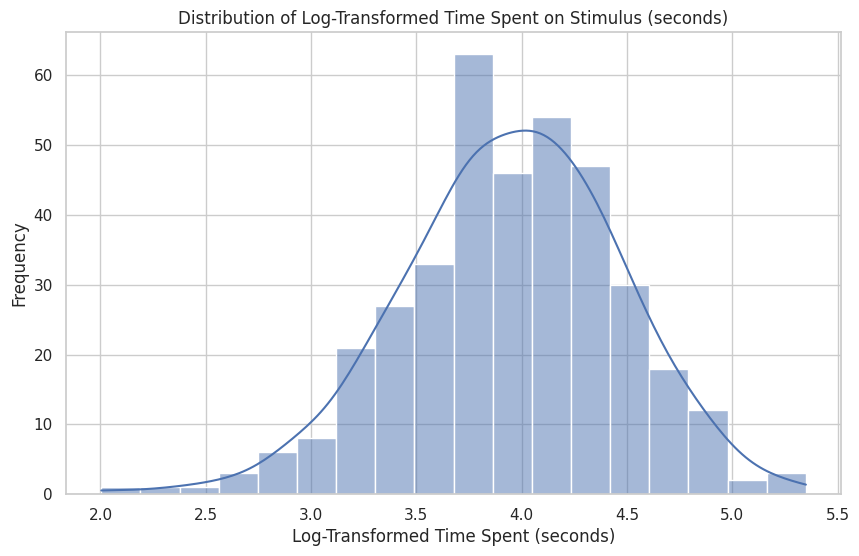

Skewness (log-transformed): -0.2838
Kurtosis (log-transformed): 0.3473
The log-transformed distribution is approximately normal based on skewness and kurtosis values.


In [ ]:
tos_seconds['log_tss_second'] = np.log(tos_seconds['tss_second'])

# Create a histogram for the log-transformed data
plt.figure(figsize=(10, 6))
sns.histplot(tos_seconds['log_tss_second'], kde=True)
plt.title('Distribution of Log-Transformed Time Spent on Stimulus (seconds)')
plt.xlabel('Log-Transformed Time Spent (seconds)')
plt.ylabel('Frequency')
plt.show()

# Create a Q-Q plot for the log-transformed data
#plt.figure(figsize=(10, 6))
#stats.probplot(tos_seconds['log_tss_second'], dist="norm", plot=plt)
#plt.title('Q-Q Plot of Log-Transformed Time Spent on Stimulus vs. Normal Distribution')
#plt.xlabel('Theoretical Quantiles')
#plt.ylabel('Sample Quantiles')
#plt.show()

# Calculate skewness and kurtosis for the log-transformed data
skewness_log = tos_seconds['log_tss_second'].skew()
kurtosis_log = tos_seconds['log_tss_second'].kurt()

print(f"Skewness (log-transformed): {skewness_log:.4f}")
print(f"Kurtosis (log-transformed): {kurtosis_log:.4f}")

if -0.5 <= skewness_log <= 0.5 and -0.5 <= kurtosis_log <= 0.5:
    print("The log-transformed distribution is approximately normal based on skewness and kurtosis values.")
elif -1 <= skewness_log <= 1 and -1 <= kurtosis_log <= 1:
    print("The log-transformed distribution is fairly symmetrical and mesokurtic, suggesting it might be close to normal.")
else:
    print("The log-transformed distribution deviates significantly from a normal distribution based on skewness and kurtosis.")

In [ ]:
timing_df['log_tta'] = np.log(timing_df['time_to_answer'])
timing_df['log_tos'] = np.log(timing_df['time_on_stimulus'])

In [ ]:
model_tta = smf.mixedlm(
    "log_tta ~ task * gender + expertise_programming_num + task_order",
    data=timing_df,
    groups=timing_df["participant_id"]
)

result_tta = model_tta.fit()
print(result_tta.summary())


                  Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       log_tta  
No. Observations:       372           Method:                   REML     
No. Groups:             186           Scale:                    0.2034   
Min. group size:        2             Log-Likelihood:           -302.9819
Max. group size:        2             Converged:                Yes      
Mean group size:        2.0                                              
-------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                       3.028    0.118 25.627 0.000  2.796  3.259
task[T.vehicle]                -0.105    0.113 -0.935 0.350 -0.327  0.116
gender[T.male]                  0.092    0.110  0.844 0.398 -0.122  0.307
task_order[T.2]                -0.100    0.047 -2.132 0.


FINDINGS — Time Taken to Answer

The linear mixed model for log-transformed time taken to answer revealed that task order was the only statistically significant predictor (β = -0.100, p = .033), with participants completing a task second responding approximately 9.5% faster than those completing it first. could indicate a  mild practice effect on response submission speed, independent of which specific task was encountered second.
Predicted time taken to answer:

- Females, rectangle task (first): exp(3.028) = 20.6 seconds (baseline)
- Females, vehicle task (first): exp(3.028 − 0.105) = exp(2.923) = 18.6 seconds
- Males, rectangle task (first): exp(3.028 + 0.092) = exp(3.120) = 22.6 seconds
- Males, vehicle task (first): exp(3.028 + 0.092 − 0.105 + 0.069) = exp(3.084) = 21.8 seconds

Task type did not significantly predict response time (p = .350), indicating that despite vehicle code generating substantially more visual processing activity, participants did not take longer to submit their answers.

Gender was non-significant (p = .398), and the gender × task interaction was also non-significant (p = .577).

Programming expertise showed no significant association with response time (p = .204).

In [ ]:
model_tos = smf.mixedlm(
    "log_tos ~ task * gender + expertise_programming_num + task_order",
    data=timing_df,
    groups=timing_df["participant_id"]
)

result_tos = model_tos.fit()
print(result_tos.summary())


                  Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       log_tos  
No. Observations:       372           Method:                   REML     
No. Groups:             186           Scale:                    0.1085   
Min. group size:        2             Log-Likelihood:           -248.0055
Max. group size:        2             Converged:                Yes      
Mean group size:        2.0                                              
-------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                       3.635    0.112 32.548 0.000  3.416  3.854
task[T.vehicle]                 0.261    0.082  3.175 0.002  0.100  0.423
gender[T.male]                  0.131    0.102  1.286 0.198 -0.069  0.332
task_order[T.2]                 0.020    0.034  0.580 0.

FINDINGS — Time on Stimulus

The linear mixed model for log-transformed time on stimulus revealed that task type was the only statistically significant predictor (β = 0.261, p = .002), with participants spending approximately 30% more time viewing the vehicle stimulus than the rectangle stimulus.

Predicted time on stimulus:

- Females, rectangle task: exp(3.635) = 37.9 seconds (baseline)
- Females, vehicle task: exp(3.635 + 0.261) = exp(3.896) = 49.2 seconds
- Males, rectangle task: exp(3.635 + 0.131) = exp(3.766) = 43.2 seconds
- Males, vehicle task: exp(3.635 + 0.131 + 0.261 − 0.089) = exp(3.938) = 51.4 seconds

Task effect: exp(0.261) = 1.30×, or 30% more time on stimulus for vehicle code across both genders, consistent with the eye-tracking findings of greater fixation counts, total fixation time, and scanpath lengths for vehicle code.

Gender was non-significant (p = .198), though the positive direction is consistent with all previous models.

The gender × task interaction was non-significant (p = .325).

Task order and programming expertise showed no significant associations (p = .562 and p = .221 respectively).



**fixation time as a proportion of stimulus time**

In [ ]:
timing_df['fixation_density'] = (
    timing_df['total_fix_time_seconds'] / timing_df['time_on_stimulus']
)


In [ ]:
timing_df['fixation_density'].describe()
timing_df['fixation_density'].skew()


np.float64(-2.4212879015156066)

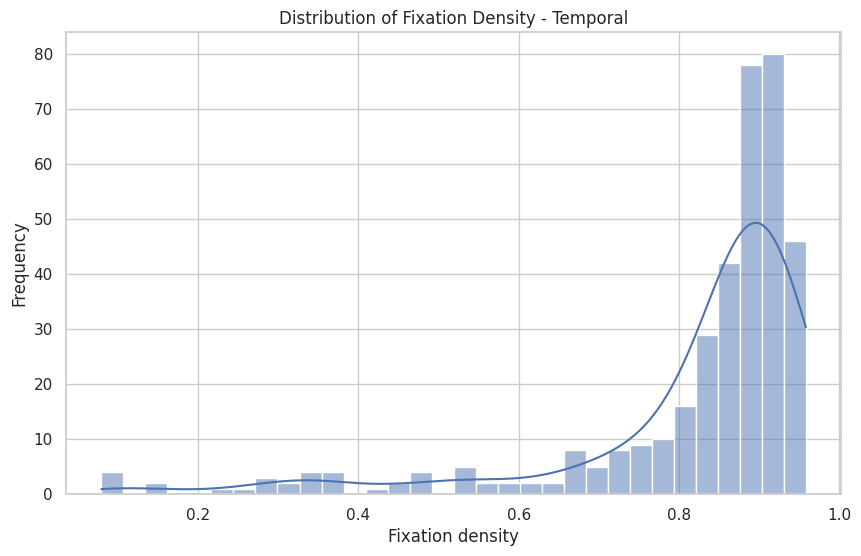

Skewness: -2.4213
Kurtosis: 5.6864
The distribution deviates significantly from a normal distribution based on skewness and kurtosis.


In [ ]:
# Create a histogram
plt.figure(figsize=(10, 6))
sns.histplot(timing_df['fixation_density'], kde=True)
plt.title('Distribution of Fixation Density - Temporal')
plt.xlabel('Fixation density')
plt.ylabel('Frequency')
plt.show()

# Calculate skewness and kurtosis
skewness = timing_df['fixation_density'].skew()
kurtosis = timing_df['fixation_density'].kurt()

print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis:.4f}")

if -0.5 <= skewness <= 0.5 and -0.5 <= kurtosis <= 0.5:
    print("The distribution is approximately normal based on skewness and kurtosis values.")
elif -1 <= skewness <= 1 and -1 <= kurtosis <= 1:
    print("The distribution is fairly symmetrical and mesokurtic, suggesting it might be close to normal.")
else:
    print("The distribution deviates significantly from a normal distribution based on skewness and kurtosis.")

In [ ]:
timing_df['log_fixation_density'] = np.log(timing_df['fixation_density'])
timing_df['logit_fixation_density'] = np.log(
    timing_df['fixation_density'] / (1 - timing_df['fixation_density'])
)


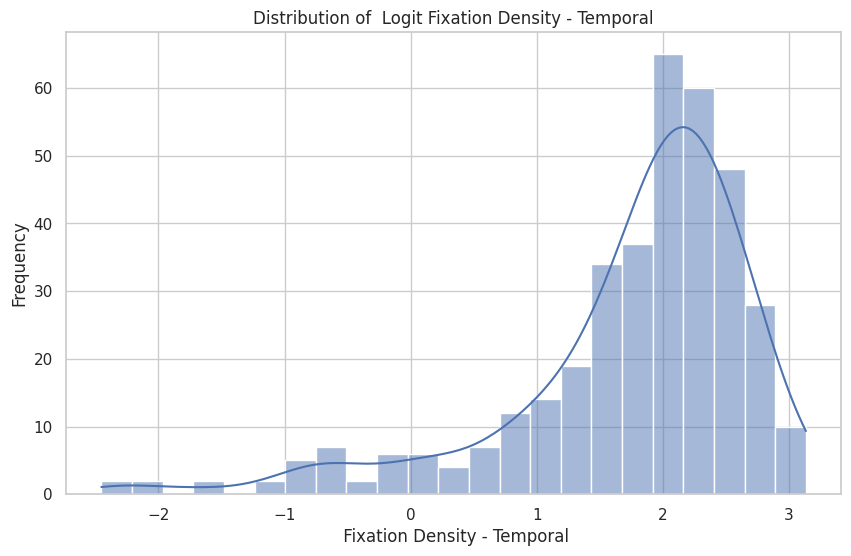

Skewness (log-transformed): -1.7567
Kurtosis (log-transformed): 3.4944
The log-transformed distribution deviates significantly from a normal distribution based on skewness and kurtosis.


In [ ]:

# Create a histogram for the logit transformed data
plt.figure(figsize=(10, 6))
sns.histplot(timing_df['logit_fixation_density'], kde=True)
plt.title('Distribution of  Logit Fixation Density - Temporal')
plt.xlabel(' Fixation Density - Temporal')
plt.ylabel('Frequency')
plt.show()

# Calculate skewness and kurtosis for the log-transformed data
skewness_log = timing_df['logit_fixation_density'].skew()
kurtosis_log = timing_df['logit_fixation_density'].kurt()

print(f"Skewness (log-transformed): {skewness_log:.4f}")
print(f"Kurtosis (log-transformed): {kurtosis_log:.4f}")

if -0.5 <= skewness_log <= 0.5 and -0.5 <= kurtosis_log <= 0.5:
    print("The log-transformed distribution is approximately normal based on skewness and kurtosis values.")
elif -1 <= skewness_log <= 1 and -1 <= kurtosis_log <= 1:
    print("The log-transformed distribution is fairly symmetrical and mesokurtic, suggesting it might be close to normal.")
else:
    print("The log-transformed distribution deviates significantly from a normal distribution based on skewness and kurtosis.")

In [ ]:
print(timing_df['fixation_density'].describe())
print("Values > 1:", (timing_df['fixation_density'] > 1).sum())
print("Values < 0:", (timing_df['fixation_density'] < 0).sum())

count    372.000000
mean       0.819404
std        0.170439
min        0.079228
25%        0.814067
50%        0.882006
75%        0.914371
max        0.958253
Name: fixation_density, dtype: float64
Values > 1: 0
Values < 0: 0


In [ ]:
model_fd = smf.mixedlm(
    "log_fixation_density ~ task * gender + expertise_programming_num + task_order",
    data=timing_df,
    groups=timing_df["participant_id"]
)

result_fd = model_fd.fit()
print(result_fd.summary())


                  Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   log_fixation_density
No. Observations:    372       Method:               REML                
No. Groups:          186       Scale:                0.0220              
Min. group size:     2         Log-Likelihood:       -43.1474            
Max. group size:     2         Converged:            Yes                 
Mean group size:     2.0                                                 
-------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                      -0.432    0.077 -5.617 0.000 -0.582 -0.281
task[T.vehicle]                 0.060    0.037  1.616 0.106 -0.013  0.133
gender[T.male]                  0.176    0.069  2.527 0.012  0.039  0.312
task_order[T.2]                -0.020    0.015 -1.318 0.

In [ ]:
timing_df['logit_fixation_density'] = np.log(
    timing_df['fixation_density'] / (1 - timing_df['fixation_density'])
)
model_fd = smf.mixedlm(
    "logit_fixation_density ~ task * gender + expertise_programming_num + task_order",
    data=timing_df,
    groups=timing_df["participant_id"]
)

result_fd = model_fd.fit()
print(result_fd.summary())


                  Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  logit_fixation_density
No. Observations:    372      Method:              REML                  
No. Groups:          186      Scale:               0.2213                
Min. group size:     2        Log-Likelihood:      -440.9473             
Max. group size:     2        Converged:           Yes                   
Mean group size:     2.0                                                 
-------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                       1.259    0.215  5.849 0.000  0.837  1.681
task[T.vehicle]                 0.120    0.118  1.021 0.307 -0.111  0.351
gender[T.male]                  0.477    0.195  2.448 0.014  0.095  0.860
task_order[T.2]                -0.101    0.049 -2.059 0.

The linear mixed model for logit-transformed fixation density revealed that gender and task order were both statistically significant predictors of the proportion of viewing time spent in active fixation.

Predicted Fixation Densities
Back-transforming all conditions to probability scale:

Females, rectangle, first: e1.2591+e1.259\frac{e^{1.259}}{1+e^{1.259}}
1+e1.259e1.259​ =
0.779 (77.9%)
Females, vehicle, first: e1.3791+e1.379\frac{e^{1.379}}{1+e^{1.379}}
1+e1.379e1.379​ =
0.799 (79.9%)
Males, rectangle, first: e1.7361+e1.736\frac{e^{1.736}}{1+e^{1.736}}
1+e1.736e1.736​ =
0.850 (85.0%)
Males, vehicle, first: e1.7881+e1.788\frac{e^{1.788}}{1+e^{1.788}}
1+e1.788e1.788​ =
0.857 (85.7%)

Second task order (subtract 0.101 from logit):

Females, rectangle, second: 0.757 (75.7%)
Males, rectangle, second: 0.835 (83.5%)

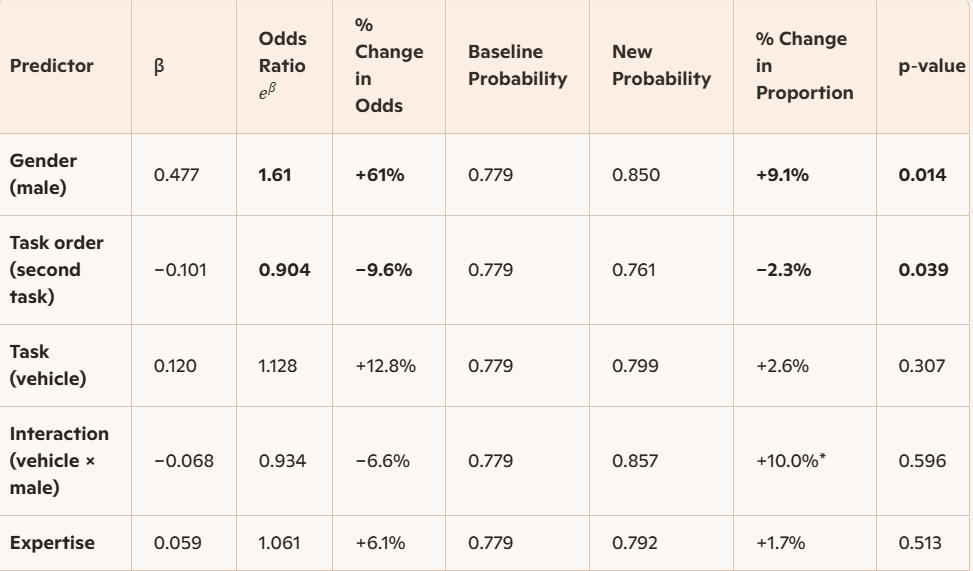

Fixation propotionate time, defined as the proportion of viewing time spent in fixations, was analysed using a logit‑transformed mixed‑effects model.

The model revealed a significant gender effect: male participants showed substantially higher fixation density than female participants (β = 0.477, p = .014), corresponding to a 61% increase in the odds of being in fixation time and an increase in predicted fixation density from 0.779 to 0.850 (+9.1%).

Task type showed a small, non‑significant tendency toward higher fixation proportion in the vehicle task (β = 0.120, p = .307), increasing the predicted proportion from 0.779 to 0.799 (+2.6%).

Task order showed a modest but significant effect (β = −0.101, p = .039), with fixation proportion decreasing from 0.779 to 0.761 (−2.3%) on the second task, indicating a mild warm‑up or efficiency effect.

The gender × task interaction was small and non‑significant (β = −0.068, p = .596), suggesting that the male advantage in fixation proportion was consistent across both tasks.

Programming expertise did not significantly predict fixation proportion (β = 0.059, p = .513).

Overall, fixation proportion reveals a robust gender difference and a small order effect, while task type and expertise exert minimal influence.